In [21]:
#import dependies
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings("ignore")
!pip install openpyxl

## 1.0 Data Cleaning

Since we only find dataset for the year 2023 and the dataset for the year range from 2011 to 2022, we would clean the two dataset sepreately and merge them as the most updated version.

Dataset Reference:

* Global Innovation Index Rank 2011-2022: https://data.mendeley.com/datasets/cvkdzr8tv3/4
* ipo-pub-2000-2023-tech1.xlsx: https://www.wipo.int/publications/en/details.jsp?id=4679

### 1.1 Dataset 1: 'wipo-pub-2000-2023-tech1.xlsx'

In [22]:
#read dataset1
data = pd.read_excel('wipo-pub-2000-2023-tech1.xlsx', sheet_name='Data')
data.head()

,ISO3,ECONOMY_NAME,NUM,NAME,DATAYR,VALUE_SCREEN,SCORE,RANK,SW_OVERALL,SW_INCGRP,OUTDATED,DMC
0,ALB,Albania,NaN,Global Innovation Index,NaN,NaN,25.426758,83.0,NaN,NaN,NaN,NaN
1,ALB,Albania,IN,Innovation inputs,NaN,NaN,35.185709,73.0,NaN,NaN,NaN,NaN
2,ALB,Albania,IN.1,Institutions,NaN,NaN,51.933820,60.0,NaN,NaN,NaN,0.0
3,ALB,Albania,IN.1.1,Institutional environment,NaN,NaN,44.714609,68.0,NaN,NaN,NaN,0.0
4,ALB,Albania,IN.1.1.1,Operational stability for businesses,2022.0,2.1,52.777778,65.0,NaN,NaN,0.0,NaN


In [23]:
#Check the columns
data.columns.tolist()

['ISO3',
 'ECONOMY_NAME',
 'NUM',
 'NAME',
 'DATAYR',
 'VALUE_SCREEN',
 'SCORE',
 'RANK',
 'SW_OVERALL',
 'SW_INCGRP',
 'OUTDATED',
 'DMC']

In [24]:
#Check the country names
data['ECONOMY_NAME'].nunique()

132

In [25]:
#Drop the irrelevant columns
df = data.drop(['ISO3','VALUE_SCREEN','NUM','SW_OVERALL','SW_INCGRP','OUTDATED','DMC','SCORE'], axis=1)
df

,ECONOMY_NAME,NAME,DATAYR,RANK
0,Albania,Global Innovation Index,NaN,83.0
1,Albania,Innovation inputs,NaN,73.0
2,Albania,Institutions,NaN,60.0
3,Albania,Institutional environment,NaN,68.0
4,Albania,Operational stability for businesses,2022.0,65.0
...,...,...,...,...
14647,Zimbabwe,Online creativity,NaN,107.0
14648,Zimbabwe,Generic top-level domains (TLDs)/th pop. 15-69,2022.0,113.0
14649,Zimbabwe,Country-code TLDs/th pop. 15-69,2022.0,80.0
14650,Zimbabwe,GitHub commits/mn pop. 15-69,2022.0,116.0


According to the Global Innovation Index 2023 Report, Page 74

Framework of the Global Innovation Index includes:

* Institutions: Institutional environment/ Regulatory environment /Business environment
* Human capital and research: Education/ Tertiary education/ Research and development (R&D)
* Infrastructure: Information and communication technologies (ICTs)/ General infrastructure /Ecological sustainability
* Market sophistication: Credit/ Investment/ Trade, diversification, and market scale
* Business sophistication Knowledge workers/ Innovation linkages/ Knowledge absorption
* Knowledge and technology outputs: Knowledge creation/ Knowledge impact / Knowledge diffusion
* Creative outputs: Intangible assets /Creative goods and services / Online creativity

In [26]:
# Remove extra spaces in column names
df.columns = df.columns.str.strip()

In [27]:
#Check the missing values
df.isna().sum(axis=0)

ECONOMY_NAME       0
NAME               0
DATAYR          5249
RANK            1184
dtype: int64

In [28]:
#Set the framwork as the factors impact global innovation
factors = ['Institutions', 'Human capital and research', 'Infrastructure', 'Market sophistication',
           'Business sophistication', 'Knowledge and technology outputs', 'Creative outputs', 'Global Innovation Index']

df_filtered = df[df['NAME'].isin(factors)]
df_filtered.head(10)

,ECONOMY_NAME,NAME,DATAYR,RANK
0,Albania,Global Innovation Index,NaN,83.0
2,Albania,Institutions,NaN,60.0
13,Albania,Human capital and research,NaN,96.0
29,Albania,Infrastructure,NaN,53.0
43,Albania,Market sophistication,NaN,93.0
57,Albania,Business sophistication,NaN,50.0
77,Albania,Knowledge and technology outputs,NaN,91.0
95,Albania,Creative outputs,NaN,87.0
111,Algeria,Global Innovation Index,NaN,119.0
113,Algeria,Institutions,NaN,97.0


In [29]:
df_filtered['DATAYR'] = 2023

In [30]:
pivot_df = df_filtered.pivot_table(index=['ECONOMY_NAME','DATAYR'], columns='NAME', values='RANK').reset_index()

In [31]:
# Group by common columns and aggregate values
result_df = pivot_df.groupby(['ECONOMY_NAME', 'DATAYR']).agg({
    'Business sophistication': 'first',
    'Creative outputs': 'first',
    'Human capital and research': 'first',
    'Infrastructure': 'first',
    'Institutions': 'first',
    'Knowledge and technology outputs': 'first',
    'Market sophistication': 'first',
    'Global Innovation Index': 'first'
}).reset_index()

In [32]:
result_df.head(10)

NAME,ECONOMY_NAME,DATAYR,Business sophistication,Creative outputs,Human capital and research,Infrastructure,Institutions,Knowledge and technology outputs,Market sophistication,Global Innovation Index
0,Albania,2023,50.0,87.0,96.0,53.0,60.0,91.0,93.0,83.0
1,Algeria,2023,120.0,107.0,113.0,102.0,97.0,128.0,125.0,119.0
2,Angola,2023,132.0,121.0,127.0,129.0,118.0,132.0,119.0,132.0
3,Argentina,2023,54.0,51.0,70.0,66.0,123.0,79.0,92.0,73.0
4,Armenia,2023,94.0,61.0,92.0,79.0,69.0,67.0,89.0,72.0
5,Australia,2023,24.0,24.0,7.0,19.0,17.0,30.0,17.0,24.0
6,Austria,2023,19.0,13.0,11.0,12.0,13.0,17.0,39.0,18.0
7,Azerbaijan,2023,64.0,100.0,87.0,95.0,42.0,114.0,85.0,89.0
8,Bahrain,2023,92.0,98.0,77.0,37.0,28.0,74.0,78.0,67.0
9,Bangladesh,2023,126.0,82.0,125.0,93.0,108.0,89.0,100.0,105.0


In [33]:
#Change the column names
result_df = result_df.rename(columns={
    'ECONOMY_NAME': 'Country',
    'DATAYR': 'Reporting Year'
})

In [34]:
#Re-organize the column order
result_df = result_df[['Country', 'Reporting Year', 'Institutions', 'Human capital and research', 'Infrastructure',
                       'Market sophistication', 'Business sophistication', 'Knowledge and technology outputs', 'Creative outputs', 'Global Innovation Index']]

In [35]:
#Round the values to keep one decimal place as shown in the report
columns_to_round = ['Institutions', 'Human capital and research', 'Infrastructure',
                    'Market sophistication', 'Business sophistication', 'Knowledge and technology outputs', 'Creative outputs', 'Global Innovation Index']

for column in columns_to_round:
    result_df[column] = result_df[column].round(0).astype(int)

result_df.head(10)

NAME,Country,Reporting Year,Institutions,Human capital and research,Infrastructure,Market sophistication,Business sophistication,Knowledge and technology outputs,Creative outputs,Global Innovation Index
0,Albania,2023,60,96,53,93,50,91,87,83
1,Algeria,2023,97,113,102,125,120,128,107,119
2,Angola,2023,118,127,129,119,132,132,121,132
3,Argentina,2023,123,70,66,92,54,79,51,73
4,Armenia,2023,69,92,79,89,94,67,61,72
5,Australia,2023,17,7,19,17,24,30,24,24
6,Austria,2023,13,11,12,39,19,17,13,18
7,Azerbaijan,2023,42,87,95,85,64,114,100,89
8,Bahrain,2023,28,77,37,78,92,74,98,67
9,Bangladesh,2023,108,125,93,100,126,89,82,105


In [36]:
result_df.shape

(132, 10)

### 1.2 Dataset 2: 'Global Innovation Index Rank 2011-2022.csv'

In [37]:
data2 = pd.read_csv('Global Innovation Index Rank 2011-2022.csv')
data2.head()

,Economies,Year,ID,Institutions,Human capital and research,Infrastructure,Market sophistication,Business sophistication,Knowledge and technology outputs,Creative outputs,Global Innovation Index,GNI per capita in current U.S. dollars,Income level (GNI Thresholds),"GDP per capita, ppp (constant 2017 international $)",GDP per capita ppp (current international $)
0,Albania,2011.0,2.0,63.0,82.0,70.0,35.0,123.0,96.0,81.0,80.0,4410.0,3.0,11052.79361,10207.76757
1,Albania,2012.0,2.0,74.0,106.0,71.0,32.0,138.0,113.0,88.0,90.0,4360.0,3.0,11227.96633,10526.25918
2,Albania,2013.0,2.0,73.0,84.0,75.0,32.0,128.0,108.0,121.0,93.0,4540.0,3.0,11361.26860,10570.96373
3,Albania,2014.0,2.0,79.0,93.0,79.0,21.0,115.0,111.0,123.0,94.0,4540.0,3.0,11586.83388,11259.26751
4,Albania,2015.0,2.0,70.0,101.0,71.0,24.0,118.0,110.0,114.0,87.0,4390.0,3.0,11878.45445,11658.90552


In [38]:
data2.columns.tolist()

['Economies',
 'Year',
 'ID',
 'Institutions',
 'Human capital and research',
 'Infrastructure',
 'Market sophistication',
 'Business sophistication',
 'Knowledge and technology outputs',
 'Creative outputs',
 'Global Innovation Index',
 'GNI per capita in current U.S. dollars ',
 'Income level (GNI Thresholds)',
 'GDP per capita, ppp (constant 2017 international $)',
 'GDP per capita ppp (current international $)']

In [39]:
# Remove extra spaces in column names
data2.columns = data2.columns.str.strip()

In [40]:
df2 = data2.drop(['ID','GNI per capita in current U.S. dollars','Income level (GNI Thresholds)','GDP per capita, ppp (constant 2017 international $)','GDP per capita ppp (current international $)'], axis=1)
df2

,Economies,Year,Institutions,Human capital and research,Infrastructure,Market sophistication,Business sophistication,Knowledge and technology outputs,Creative outputs,Global Innovation Index
0,Albania,2011.0,63.0,82.0,70.0,35.0,123.0,96.0,81.0,80.0
1,Albania,2012.0,74.0,106.0,71.0,32.0,138.0,113.0,88.0,90.0
2,Albania,2013.0,73.0,84.0,75.0,32.0,128.0,108.0,121.0,93.0
3,Albania,2014.0,79.0,93.0,79.0,21.0,115.0,111.0,123.0,94.0
4,Albania,2015.0,70.0,101.0,71.0,24.0,118.0,110.0,114.0,87.0
...,...,...,...,...,...,...,...,...,...,...
1787,Zimbabwe,2022.0,128.0,92.0,126.0,114.0,90.0,99.0,89.0,107.0
1788,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1789,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1790,Notas:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
df2.rename(columns={'Economies': 'Country', 'Year':'Reporting Year'}, inplace=True)

In [42]:
#Remove the missing values from the dataset
df2['Global Innovation Index'].replace(' ', np.nan, inplace=True)
df2.dropna(subset=['Global Innovation Index'], inplace=True)

In [43]:
#Check the missing values
df2.isna().sum(axis=0)

Country                             0
Reporting Year                      0
Institutions                        0
Human capital and research          0
Infrastructure                      0
Market sophistication               0
Business sophistication             0
Knowledge and technology outputs    0
Creative outputs                    0
Global Innovation Index             0
dtype: int64

In [44]:
columns_round = ['Reporting Year', 'Institutions', 'Human capital and research', 'Infrastructure', 'Market sophistication', 'Business sophistication', 'Knowledge and technology outputs', 'Creative outputs', 'Global Innovation Index']

for column in columns_round:
    df2[column] = df2[column].round(0).astype(int)


In [45]:
df2.head(10)

,Country,Reporting Year,Institutions,Human capital and research,Infrastructure,Market sophistication,Business sophistication,Knowledge and technology outputs,Creative outputs,Global Innovation Index
0,Albania,2011,63,82,70,35,123,96,81,80
1,Albania,2012,74,106,71,32,138,113,88,90
2,Albania,2013,73,84,75,32,128,108,121,93
3,Albania,2014,79,93,79,21,115,111,123,94
4,Albania,2015,70,101,71,24,118,110,114,87
5,Albania,2016,64,90,64,30,114,106,119,92
6,Albania,2017,62,91,66,41,102,118,100,93
7,Albania,2018,55,95,62,38,98,110,86,83
8,Albania,2019,56,88,66,42,105,114,74,83
9,Albania,2020,56,95,65,70,73,119,72,83


### 1.3 Merge the two datasets

In [46]:
merged_df = pd.merge(result_df, df2, on=None, how='outer')
merged_df = merged_df.sort_values(by=['Country', 'Reporting Year'], ascending=[True, True])

In [47]:
merged_df = merged_df.reset_index(drop=True)
merged_df.head(15)

,Country,Reporting Year,Institutions,Human capital and research,Infrastructure,Market sophistication,Business sophistication,Knowledge and technology outputs,Creative outputs,Global Innovation Index
0,Albania,2011,63,82,70,35,123,96,81,80
1,Albania,2012,74,106,71,32,138,113,88,90
2,Albania,2013,73,84,75,32,128,108,121,93
3,Albania,2014,79,93,79,21,115,111,123,94
4,Albania,2015,70,101,71,24,118,110,114,87
5,Albania,2016,64,90,64,30,114,106,119,92
6,Albania,2017,62,91,66,41,102,118,100,93
7,Albania,2018,55,95,62,38,98,110,86,83
8,Albania,2019,56,88,66,42,105,114,74,83
9,Albania,2020,56,95,65,70,73,119,72,83


In [48]:
merged_df.shape

(1729, 10)

In [49]:
merged_df['Country'].unique()

array(['Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia',
       'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia (Plurinational State of)', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria',
       'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon',
       'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica',
       "Cote d'Ivoire", 'Croatia', 'Cyprus', 'Czech Republic', 'Czechia',
       "CÃ´te d'Ivoire", 'Denmark', 'Dominican Republic', 'Ecuador',
       'Egypt', 'El Salvador', 'Estonia', 'Ethiopia', 'Fiji', 'Finland',
       'France', 'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana',
       'Greece', 'Guatemala', 'Guinea', 'Guyana', 'Honduras',
       'Hong Kong (China)', 'Hong Kong, China', 'Hungary', 'Iceland',
       'India', 'Indonesia', 'Iran (Islamic Republic of)', 'Iraq',
       'Ireland', 'Israel', 'Italy', 'Jamaica', 'Ja

In [50]:
merged_df['Country'] = merged_df['Country'].replace('Republic of Korea (the)', 'Korea')
merged_df['Country'] = merged_df['Country'].replace('United Kingdom', 'UK')
merged_df['Country'] = merged_df['Country'].replace('United States of America', 'USA')

In [51]:
merged_df['Country'].nunique()

160

## 2.0 Feature Importance

### 2.1 Correlation Matrix for Global Innovation Index

Correlation analysis is a statistical technique primarily used for measuring linear relationships, and may overlook non-linear associations.

In [52]:
selected_columns = ['Institutions', 'Human capital and research', 'Infrastructure', 'Market sophistication', 'Business sophistication', 'Knowledge and technology outputs', 'Creative outputs', 'Global Innovation Index']
df_selected = merged_df[selected_columns]

# Calculate the correlation matrix
correlation_matrix = df_selected.corr()

# Extract the correlation of each feature with Global Innovation Index
correlation_with_innovation = correlation_matrix['Global Innovation Index']
print("Correlation of Features with Global Innovation Index:")
print(correlation_with_innovation)

Correlation of Features with Global Innovation Index:
Institutions                        0.849471
Human capital and research          0.883798
Infrastructure                      0.905012
Market sophistication               0.790933
Business sophistication             0.834969
Knowledge and technology outputs    0.874067
Creative outputs                    0.912334
Global Innovation Index             1.000000
Name: Global Innovation Index, dtype: float64


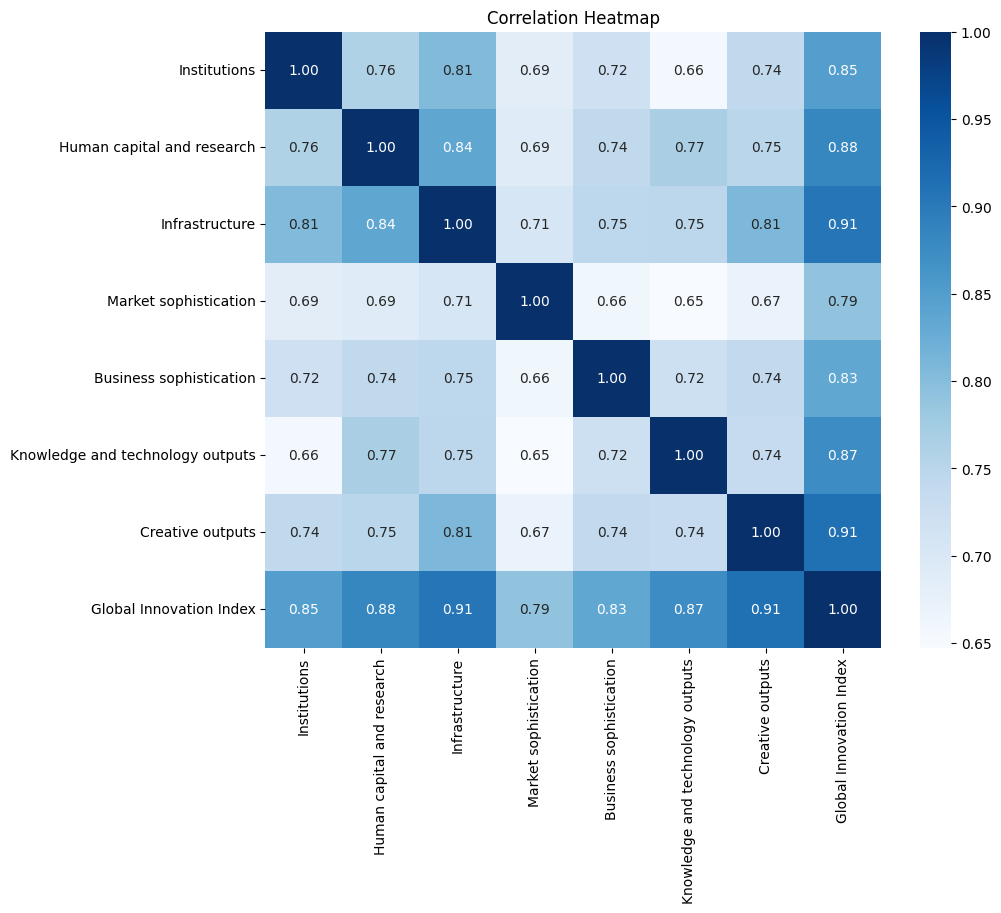

In [53]:
# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f", square=True)
plt.title('Correlation Heatmap')
plt.show()

### 2.2 Feature Importance - Random Forest Regressor

RandomForest Regression is an ensemble method based on decision trees, which can better handle non-linear relationships and interactions.

Random Forest Regressor was chosen for feature importance analysis because it excels in handling complex, nonlinear relationships in data, is robust to outliers, offers diversity through ensemble learning, provides built-in feature importance calculation, and results in interpretable findings. It's a powerful choice for identifying the most influential factors affecting the target variable.

In [54]:
X = merged_df[['Institutions', 'Human capital and research', 'Infrastructure', 'Market sophistication', 'Business sophistication', 'Knowledge and technology outputs', 'Creative outputs']]
y = merged_df['Global Innovation Index']

# Create a RandomForestRegressor model
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf.fit(X, y)

# Get feature importances and create a list
feature_importance = rf.feature_importances_
feature_importance_list = list(zip(X.columns, feature_importance))

# Sort the list by importance in descending order
feature_importance_list = sorted(feature_importance_list, key=lambda x: x[1], reverse=True)

# Create a DataFrame
feature_importance_df = pd.DataFrame({'Feature': [x[0] for x in feature_importance_list], 'Importance': [x[1] for x in feature_importance_list]})
feature_importance_df

,Feature,Importance
0,Creative outputs,0.602829
1,Infrastructure,0.129869
2,Knowledge and technology outputs,0.095363
3,Human capital and research,0.077426
4,Business sophistication,0.052993
5,Institutions,0.024890
6,Market sophistication,0.016630


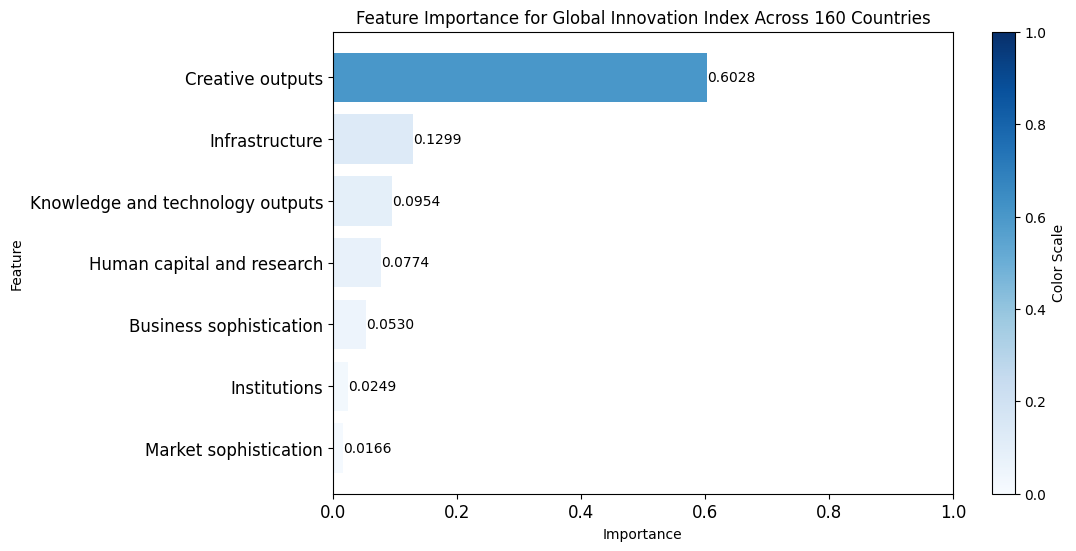

In [55]:
# Plot feature importance chart
colors = colors = plt.cm.Blues(feature_importance_df['Importance'])
plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color=colors)

for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.4f}', ha='left', va='center')

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for Global Innovation Index Across 160 Countries')

plt.yticks(fontsize=12)
plt.xlim(0, 1)
plt.xticks(fontsize=12)

# Sort the bars in descending order of importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Add color bar
color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap='Blues'), ax=plt.gca(), orientation='vertical')
color_bar.set_label('Color Scale')
# Invert the y-axis
plt.gca().invert_yaxis()
plt.show()

### 2.3 Compare between Different Countries

In [56]:
#Check the top 20 countries by ranking
top_countries = merged_df[merged_df['Global Innovation Index'] < 20]['Country'].unique().tolist()
top_countries

['Australia',
 'Austria',
 'Canada',
 'China',
 'Denmark',
 'Estonia',
 'Finland',
 'France',
 'Germany',
 'Hong Kong (China)',
 'Hong Kong, China',
 'Iceland',
 'Ireland',
 'Israel',
 'Japan',
 'Luxembourg',
 'Malta',
 'Netherlands',
 'New Zealand',
 'Norway',
 'Republic of Korea',
 'Korea',
 'Singapore',
 'Sweden',
 'Switzerland',
 'UK',
 'USA']

##### Select the coutries provided report
* Canada
* United Kingdom
* Singapore
* United States of America
* Switzerland
* Japan

In [57]:
countries = merged_df[(merged_df['Country'] == 'Canada') | (merged_df['Country'] == 'UK') | (merged_df['Country'] == 'Singapore') | (merged_df['Country'] == 'USA') | (merged_df['Country'] == 'Switzerland') | (merged_df['Country'] == 'Japan')].reset_index(drop=True)
countries

,Country,Reporting Year,Institutions,Human capital and research,Infrastructure,Market sophistication,Business sophistication,Knowledge and technology outputs,Creative outputs,Global Innovation Index
0,Canada,2011,3,19,3,9,10,21,4,8
1,Canada,2012,2,25,15,7,14,22,16,12
2,Canada,2013,5,25,15,4,16,17,11,11
3,Canada,2014,7,13,13,5,15,21,16,12
4,Canada,2015,6,22,11,4,18,21,18,16
...,...,...,...,...,...,...,...,...,...,...
73,USA,2019,11,12,23,1,7,4,15,3
74,USA,2020,9,12,24,2,5,3,11,3
75,USA,2021,12,11,23,2,2,3,12,3
76,USA,2022,13,9,19,1,3,3,12,2


In [58]:
X = countries[['Institutions', 'Human capital and research', 'Infrastructure', 'Market sophistication', 'Business sophistication', 'Knowledge and technology outputs', 'Creative outputs']]
y = countries['Global Innovation Index']

# Create a RandomForestRegressor model
rf_new = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_new.fit(X, y)

# Get feature importances and create a list
feature_importance_new = rf_new.feature_importances_
feature_importance_new_list = list(zip(X.columns, feature_importance_new))

# Sort the list by importance in descending order
feature_importance_new_list = sorted(feature_importance_new_list, key=lambda x: x[1], reverse=True)

# Create a DataFrame
feature_importance_df_new = pd.DataFrame({'Feature': [x[0] for x in feature_importance_new_list], 'Importance': [x[1] for x in feature_importance_new_list]})
feature_importance_df_new

,Feature,Importance
0,Knowledge and technology outputs,0.532184
1,Human capital and research,0.222401
2,Creative outputs,0.118369
3,Business sophistication,0.052958
4,Market sophistication,0.047122
5,Institutions,0.016666
6,Infrastructure,0.010299


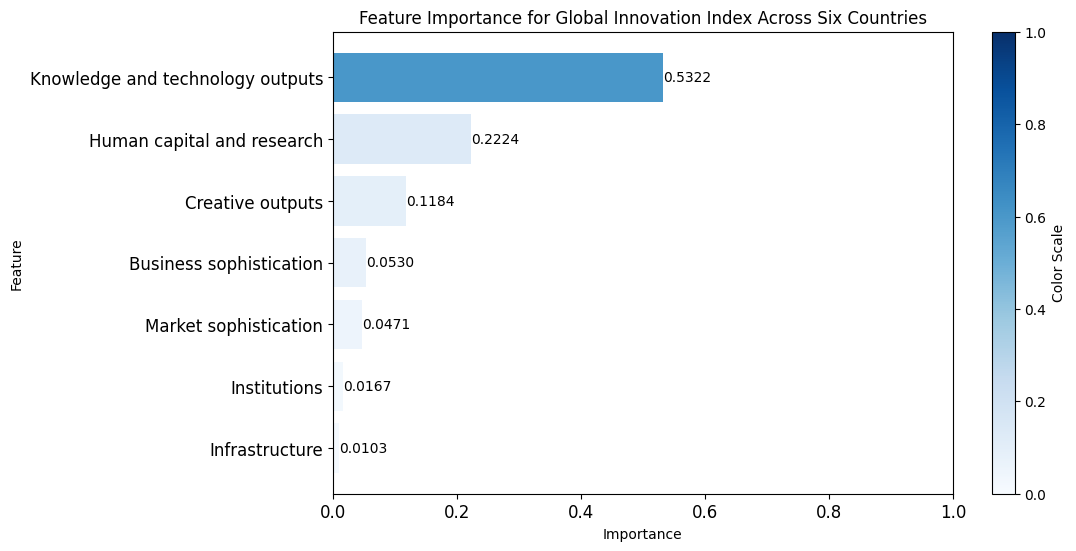

In [59]:
# Plot feature importance chart
colors = colors = plt.cm.Blues(feature_importance_df['Importance'])
plt.figure(figsize=(10, 6))
bars = plt.barh(feature_importance_df_new['Feature'], feature_importance_df_new['Importance'], color=colors)

for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.4f}', ha='left', va='center')

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for Global Innovation Index Across Six Countries')

plt.yticks(fontsize=12)
plt.xlim(0, 1)
plt.xticks(fontsize=12)

# Sort the bars in descending order of importance
feature_importance_df_new = feature_importance_df_new.sort_values(by='Importance', ascending=False)

# Add color bar
color_bar = plt.colorbar(plt.cm.ScalarMappable(cmap='Blues'), ax=plt.gca(), orientation='vertical')
color_bar.set_label('Color Scale')
# Invert the y-axis
plt.gca().invert_yaxis()
plt.show()

We have chosen six countries that rank within the top 20 of the Global Innovation Index, including Canada, the UK, Singapore, the USA, Switzerland, and Japan. Notably, our analysis revealed a shift in feature importance rankings when compared to the results obtained from analyzing all countries. In this updated analysis, 'Knowledge and technology outputs' emerged as the most influential feature, with an importance score of 0.5322. It was followed by 'Human capital and research' at 0.2224 and 'Creative outputs' at 0.1184 in terms of importance. In contrast, the analysis encompassing all countries identified 'Creative outputs' as the most crucial feature at 0.6028, followed by 'Infrastructure' at 0.1299, and 'Knowledge and technology outputs' at 0.0954.

It's essential to recognize that the relative importance of factors may vary among countries. Therefore, when designing an innovation strategy for Canada, we should tailor our approach to the specific strengths and weaknesses within our national context. For Canada, focusing on strengthening 'Knowledge and technology outputs' and 'Human capital and research' could yield promising results, given their high importance scores in our analysis.

In addition, while 'Creative outputs' ranked lower in importance among these six countries, it remains a crucial driver of innovation on a global scale. Incorporating creative strategies and fostering a culture of innovation should remain a fundamental part of Canada's innovation strategy.

In [60]:
# Canada Data
canada_data = countries[countries['Country'] == 'Canada']
canada_data

,Country,Reporting Year,Institutions,Human capital and research,Infrastructure,Market sophistication,Business sophistication,Knowledge and technology outputs,Creative outputs,Global Innovation Index
0,Canada,2011,3,19,3,9,10,21,4,8
1,Canada,2012,2,25,15,7,14,22,16,12
2,Canada,2013,5,25,15,4,16,17,11,11
3,Canada,2014,7,13,13,5,15,21,16,12
4,Canada,2015,6,22,11,4,18,21,18,16
5,Canada,2016,6,22,11,3,20,23,23,15
6,Canada,2017,7,20,18,3,24,19,27,18
7,Canada,2018,5,18,20,3,24,22,30,18
8,Canada,2019,4,19,27,2,22,19,27,17
9,Canada,2020,6,19,29,3,20,21,17,17


2023 Rank:
* Human capital and research: 10
* Creative outputs: 22
* Infrastructure: 30
* Knowledge and technology outputs: 19

In [61]:
avg_values_by_country = countries.groupby('Country').mean().drop(columns='Reporting Year').round(2)
avg_values_by_country

,Institutions,Human capital and research,Infrastructure,Market sophistication,Business sophistication,Knowledge and technology outputs,Creative outputs,Global Innovation Index
Country,,,,,,,,
Canada,6.54,18.62,19.38,4.15,18.54,20.92,19.23,14.62
Japan,15.46,17.54,9.31,12.08,13.15,12.85,39.23,16.92
Singapore,3.08,4.00,6.85,4.46,2.15,11.31,29.31,6.31
Switzerland,10.00,8.15,7.77,6.38,4.23,1.08,2.08,1.00
UK,15.00,10.08,7.23,3.77,14.92,8.92,6.46,4.23
USA,14.62,13.08,18.85,1.54,7.00,4.85,16.77,4.69


Canada's ‘Institutions’ and ‘Market Sophistication’ have commendably maintained average rankings around the 6th and 4th positions respectively. However, areas such as ‘Human Capital and Research’ and ‘Knowledge and Technology Outputs’ lagged, with average rankings of approximately 19th and 21st, respectively. These findings pinpoint these two features as focal points for our subsequent research.

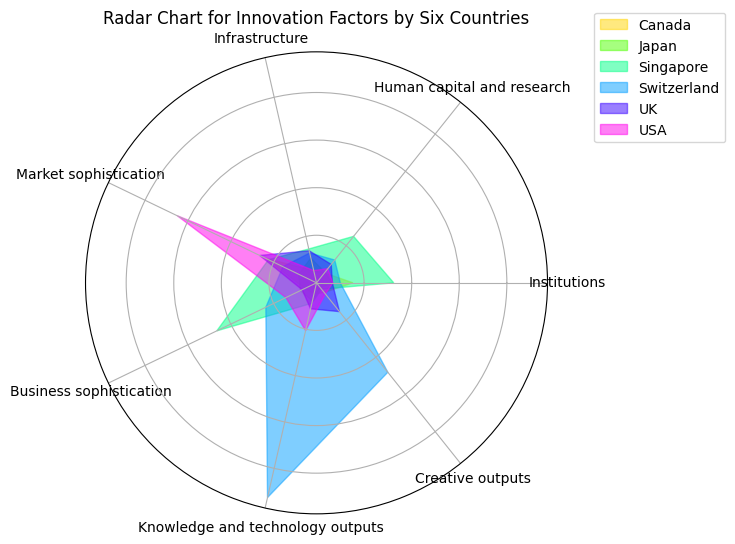

In [62]:
# Fill in the data (excluding Global Innovation Index)
countries = avg_values_by_country.index
factors = avg_values_by_country.columns.drop('Global Innovation Index')
data = 1 / avg_values_by_country.drop('Global Innovation Index', axis=1).values.T

# Create a Radar Chart
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
num_factors = len(factors)

# Calculate angles to evenly divide the Radar Chart for different factors
angles = np.linspace(0, 2 * np.pi, num_factors, endpoint=False).tolist()
# Close the shape
angles += angles[:1]

colors = sns.color_palette("hsv", len(countries))

for i, country in enumerate(countries):
    values = data[:, i].tolist()
    values += values[:1]
    ax.fill(angles, values, alpha=0.5, label=country, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(factors)
ax.set_yticklabels([])
ax.set_title('Radar Chart for Innovation Factors by Six Countries')
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1))
plt.show()

A radar chart illustrating innovation factors for the six countries revealed distinct strengths. Switzerland stood out, consistently ranking first with a pronounced lead in ‘Knowledge and Technology Outputs’. Compared to Canada, the other five countries had higher average rankings in these two features. Notably, Singapore ranked around 4th in ‘Human Capital and Research’, and the United States ranked about 5th in ‘Knowledge and Technology Outputs’. This suggests that these countries’ innovation strategies could provide valuable lessons for enhancing Canada's performance in these critical sectors.


## 3.0 Summarize PDFs by Using OpenAI API

In [63]:
!pip install openai
!pip install PyPDF2
!pip install pdfplumber

import requests
import os

import requests
import pdfplumber
import openai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.4/221.4 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 6.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
llmx 0.0.15a0 requires cohere, which is not installed.
llmx 0.0.15a0 requires tiktoken, which is not installed.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 1.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.0/49.0 kB 927.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 29.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 80.5 MB/s eta 0:00:00


In [64]:
!pip install openai==0.28

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 1.3 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.3.7
    Uninstalling openai-1.3.7:
      Successfully uninstalled openai-1.3.7
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
llmx 0.0.15a0 requires cohere, which is not installed.
llmx 0.0.15a0 requires tiktoken, which is not installed.


In [65]:
# API Key
# API_KEY = "***"
# os.environ['OPENAI_API_KEY'] = API_KEY
# openai.api_key = os.getenv("OPENAI_API_KEY")

In [66]:
# OpenAI API parameters
model = "gpt-3.5-turbo"  # 4K tokens
max_tokens = 1024
n = 1
stop = None
temperature = 0.5

### 3.1 Country: Canada


Global Innovation Index 2023 Page 101

#### 3.1.1 annual-report-2017-2018-eng

In [67]:
# # Download the PDF file
# pdf_url = "https://drive.google.com/uc?export=download&id=1DrfkOwiXEJQ78kkFpLWg3WwUsQ171Vo8"
# response = requests.get(pdf_url)
# with open('annual-report-2017-2018-eng.pdf', 'wb') as f:
#     f.write(response.content)

# # Extract text from the PDF
# ca_text1 = ""
# with pdfplumber.open('annual-report-2017-2018-eng.pdf') as pdf:
#     print("Number of pages in PDF document:", len(pdf.pages))
#     for page in pdf.pages:
#         ca_text1 += page.extract_text()

Number of pages in PDF document: 22

In [68]:
# prompt1 = 'I want you to act as a report summarizer. I will provide you with a report on a specific topic, and you will create a summary of the main points and findings of the paper. If the report mentions any policy or any strategy, please list them in your summary. Your summary should be concise and should accurately and objectively communicate the key points of the report. You should not include any personal opinions or interpretations in your summary, but rather focus on objectively presenting the information from the report. Your summary should be written in your own words and should not include any direct quotes from the paper. Please ensure that your summary is clear, concise, and accurately reflects the content of the original report: "{input}".'.format(input=ca_text1)

In [69]:
# Call OpenAI API
'''
response_ca1 = openai.ChatCompletion.create(
    model=model,
    messages=[
    {"role": "system", "content": "You are a helpful  assistant."},
    {"role": "user", "content": prompt1[:min(len(prompt1),11000)]},
    ],
    max_tokens=max_tokens,
    n=n,
    stop=stop,
    temperature=temperature,
)
'''

'\nresponse_ca1 = openai.ChatCompletion.create(\n    model=model,\n    messages=[\n    {"role": "system", "content": "You are a helpful  assistant."},\n    {"role": "user", "content": prompt1[:min(len(prompt1),11000)]},\n    ],\n    max_tokens=max_tokens,\n    n=n,\n    stop=stop,\n    temperature=temperature,\n)\n'

In [70]:
'''
output_ca1 = response_ca1['choices'][0]['message']['content']
print(output_ca1)
'''

"\noutput_ca1 = response_ca1['choices'][0]['message']['content']\nprint(output_ca1)\n"

The Canadian Intellectual Property Office (CIPO) has released its Annual Report for 2017-2018. The report highlights the agency's efforts to make Canada a global center of innovation and outlines its five-year business strategy. The main priorities of the strategy are to advance innovation, deliver quality and timely IP rights, build IP awareness and education, offer a modern service experience, and foster an agile and high-performing organization.

In terms of achievements, CIPO reached significant milestones in implementing international IP treaties for industrial design, trademarks, and patents. They expect to complete accession to the Hague Agreement for industrial design in November 2018. CIPO also launched an IP awareness and education program to equip Canadian innovators with the knowledge they need to succeed.

The report emphasizes the importance of a modern and robust IP regime in supporting Canada's innovation economy. CIPO is actively working towards harmonization of the global IP system and has been moving ahead to ratify five international IP treaties. Joining these treaties will provide Canadian businesses with a faster and more cost-effective way to acquire IP rights in multiple countries, attracting foreign investment and facilitating international competitiveness and trade.

CIPO has also been involved in policy changes, such as expanding Canada's geographical indication (GI) system under the Canada-European Union Comprehensive Economic and Trade Agreement (CETA). This allows for the protection of agricultural products and food with specific geographical origins. CIPO developed new administrative procedures and implemented system changes to accommodate these additions.

Overall, the report highlights CIPO's commitment to supporting innovation and economic success in Canada through the administration of IP rights and the implementation of strategic initiatives.

#### 3.1.2 innovation_challenges_report_-_en_final_oct14

In [71]:
# # Download the PDF file

# pdf_url = "https://drive.google.com/uc?export=download&id=1qUrmxWjp9ftfqv1O4OTUpH3GbAkw1qci"
# response = requests.get(pdf_url)
# with open('innovation_challenges_report_-_en_final_oct14.pdf', 'wb') as f:
#     f.write(response.content)

# # Extract text from the PDF
# ca_text2 = ""
# with pdfplumber.open('innovation_challenges_report_-_en_final_oct14.pdf') as pdf:
#     print("Number of pages in PDF document:", len(pdf.pages))
#     for page in pdf.pages:
#         ca_text2 += page.extract_text()


Number of pages in PDF document: 22

In [72]:
# prompt2 = 'I want you to act as a report summarizer. I will provide you with a report on a specific topic, and you will create a summary of the main points and findings of the paper. If the report mentions any policy or any strategy, please list them in your summary. Your summary should be concise and should accurately and objectively communicate the key points of the report. You should not include any personal opinions or interpretations in your summary, but rather focus on objectively presenting the information from the report. Your summary should be written in your own words and should not include any direct quotes from the paper. Please ensure that your summary is clear, concise, and accurately reflects the content of the original report: "{input}".'.format(input=ca_text2)

In [73]:
# Call OpenAI API
'''
response_ca2 = openai.ChatCompletion.create(
    model=model,
    messages=[
    {"role": "system", "content": "You are a helpful  assistant."},
    {"role": "user", "content": prompt2[:min(len(prompt2),11000)]},
    ],
    max_tokens=max_tokens,
    n=n,
    stop=stop,
    temperature=temperature,
)
'''

'\nresponse_ca2 = openai.ChatCompletion.create(\n    model=model,\n    messages=[\n    {"role": "system", "content": "You are a helpful  assistant."},\n    {"role": "user", "content": prompt2[:min(len(prompt2),11000)]},\n    ],\n    max_tokens=max_tokens,\n    n=n,\n    stop=stop,\n    temperature=temperature,\n)\n'

In [74]:
'''
output_ca2 = response_ca2['choices'][0]['message']['content']
print(output_ca2)
'''

"\noutput_ca2 = response_ca2['choices'][0]['message']['content']\nprint(output_ca2)\n"

This report explores the barriers limiting the innovation performance of Canadian SMEs and how they are using talent from work-integrated-learning (WIL) programs to address these challenges. The main findings are as follows:

1. Canada's innovation performance is hindered by the limited capacity of its nearly 1.15 million SMEs to innovate.

2. Key barriers to innovation for SMEs include limited access to talent, financing, rising input costs, and unstable market demand.

3. The Covid-19 pandemic has further exacerbated these issues, making it harder for SMEs to recruit skilled workers and invest in digital technologies.

4. The report analyzes project applications submitted to Mitacs's Business Strategy Internship (BSI) program, revealing that talent access is a major issue inhibiting SME innovation performance.

5. Skilled talent acquired through WIL programs can help drive SME innovation, encourage product and market diversification, technological upgrading, and sustainable growth trajectories.

The report emphasizes the importance of addressing talent access as a key factor in unlocking the innovation potential of Canadian SMEs. It suggests that leveraging talent from WIL programs can help SMEs overcome their innovation challenges and contribute to their long-term success.

#### 3.1.3 mitacs_-_joining_the_dots_en

In [75]:
# # Download the PDF file
# pdf_url = "https://drive.google.com/uc?export=download&id=1pk7XlvWxYh83AEZn6-8ndf_cNw9lhizN"
# response = requests.get(pdf_url)
# with open('mitacs_-_joining_the_dots_en.pdf', 'wb') as f:
#     f.write(response.content)

# # Extract text from the PDF
# ca_text3 = ""
# with pdfplumber.open('mitacs_-_joining_the_dots_en.pdf') as pdf:
#     print("Number of pages in PDF document:", len(pdf.pages))
#     for page in pdf.pages:
#         ca_text3 += page.extract_text()

Number of pages in PDF document: 55

In [76]:
# prompt3 = 'I want you to act as a report summarizer. I will provide you with a report on a specific topic, and you will create a summary of the main points and findings of the paper. If the report mentions any policy or any strategy, please list them in your summary. Your summary should be concise and should accurately and objectively communicate the key points of the report. You should not include any personal opinions or interpretations in your summary, but rather focus on objectively presenting the information from the report. Your summary should be written in your own words and should not include any direct quotes from the paper. Please ensure that your summary is clear, concise, and accurately reflects the content of the original report: "{input}".'.format(input=ca_text3)

In [77]:
# Call OpenAI API
'''
response_ca3 = openai.ChatCompletion.create(
    model=model,
    messages=[
    {"role": "system", "content": "You are a helpful  assistant."},
    {"role": "user", "content": prompt3[:min(len(prompt3),11000)]},
    ],
    max_tokens=max_tokens,
    n=n,
    stop=stop,
    temperature=temperature,
)'''

'\nresponse_ca3 = openai.ChatCompletion.create(\n    model=model,\n    messages=[\n    {"role": "system", "content": "You are a helpful  assistant."},\n    {"role": "user", "content": prompt3[:min(len(prompt3),11000)]},\n    ],\n    max_tokens=max_tokens,\n    n=n,\n    stop=stop,\n    temperature=temperature,\n)'

In [78]:
'''
output_ca3 = response_ca3['choices'][0]['message']['content']
print(output_ca3)
'''

"\noutput_ca3 = response_ca3['choices'][0]['message']['content']\nprint(output_ca3)\n"

This report examines the role of Mitacs as an innovation intermediary in Canada. Mitacs is an organization that facilitates collaborations between academia and industry to tackle industry challenges. The report explores Mitacs's research and innovation support model, which includes engaging interns in collaborative research projects and supporting academia-industry partnerships through various programs. Mitacs also operates a Canada-wide network of experts to engage with research and innovation partners. The report highlights the barriers to academic-industry collaboration and how Mitacs acts as an intermediary to build and strengthen these linkages. It discusses the importance of personal networks, trust, and reputation in Mitacs's success as an innovation intermediary. The report also emphasizes the value of coordination and coherence with other innovation support actors and the trade-off between maximizing repeat business and developing new partnerships. Overall, Mitacs plays a crucial role in fostering academic-industry collaborations and driving innovation in Canada.

#### 3.1.4 mitacs_skills_innovation_en

In [79]:
# # Download the PDF file
# pdf_url = "https://drive.google.com/uc?export=download&id=1cyov9ED2zqvXPsSzNr8IIx4nNSvFF9VH"
# response = requests.get(pdf_url)
# with open('mitacs_skills_innovation_en.pdf', 'wb') as f:
#     f.write(response.content)

# # Extract text from the PDF
# ca_text4 = ""
# with pdfplumber.open('mitacs_skills_innovation_en.pdf') as pdf:
#     print("Number of pages in PDF document:", len(pdf.pages))
#     for page in pdf.pages:
#         ca_text4 += page.extract_text()

Number of pages in PDF document: 41

In [80]:
# prompt4 = 'I want you to act as a report summarizer. I will provide you with a report on a specific topic, and you will create a summary of the main points and findings of the paper. If the report mentions any policy or any strategy, please list them in your summary. Your summary should be concise and should accurately and objectively communicate the key points of the report. You should not include any personal opinions or interpretations in your summary, but rather focus on objectively presenting the information from the report. Your summary should be written in your own words and should not include any direct quotes from the paper. Please ensure that your summary is clear, concise, and accurately reflects the content of the original report: "{input}".'.format(input=ca_text4)

In [81]:
# Call OpenAI API
'''
response_ca4 = openai.ChatCompletion.create(
    model=model,
    messages=[
    {"role": "system", "content": "You are a helpful  assistant."},
    {"role": "user", "content": prompt4[:min(len(prompt4),11000)]},
    ],
    max_tokens=max_tokens,
    n=n,
    stop=stop,
    temperature=temperature,
)'''

'\nresponse_ca4 = openai.ChatCompletion.create(\n    model=model,\n    messages=[\n    {"role": "system", "content": "You are a helpful  assistant."},\n    {"role": "user", "content": prompt4[:min(len(prompt4),11000)]},\n    ],\n    max_tokens=max_tokens,\n    n=n,\n    stop=stop,\n    temperature=temperature,\n)'

In [82]:
'''
output_ca4 = response_ca4['choices'][0]['message']['content']
print(output_ca4)
'''

"\noutput_ca4 = response_ca4['choices'][0]['message']['content']\nprint(output_ca4)\n"

The report titled "Mitacs Skills for Innovation: Sharpening Canada's skills advantage" provides insights into the skills needed for innovation in Canada. The report is based on a survey of organizations and interns involved in Mitacs's Elevate and Accelerate programs.

The report highlights the importance of sharpening Canadians' skills and knowledge to improve innovation performance. It identifies both general skills and specialized skills required for innovation.

General skills identified include curiosity, creativity, basic data and digital skills, scientific principles and methods, and certain social and emotional skills like collaboration and communication. However, other social and emotional skills such as empathy and emotional control were rarely mentioned.

Specialized skills identified include advanced data and digital skills, management skills, and design skills. These skills are particularly important for firms engaged in developing technology internally, but may not be required for other types of innovation.

The report also notes that interns' confidence in their skills often lags behind the frequency with which they use certain skills, indicating areas for improvement in Canadians' skills for innovation.

Overall, the report emphasizes the need for a diverse set of skills and knowledge to address different kinds of innovation. It suggests that educators, businesses, students, and workers should develop better strategies for talent development and recruitment to enhance innovation success in Canada.

No specific policy or strategy is mentioned in the report.

#### bridging_the_gap_en

In [83]:
# # Download the PDF file
# pdf_url = "https://drive.google.com/uc?export=download&id=1qtUt361uPL_7aMNhc4rk9eur4A1UGQka"
# response = requests.get(pdf_url)
# with open('bridging_the_gap_en.pdf', 'wb') as f:
#     f.write(response.content)

# # Extract text from the PDF
# ca_text5 = ""
# with pdfplumber.open('bridging_the_gap_en.pdf') as pdf:
#     print("Number of pages in PDF document:", len(pdf.pages))
#     for page in pdf.pages:
#         ca_text5 += page.extract_text()

Number of pages in PDF document: 24

In [84]:
# prompt5 = 'I want you to act as a report summarizer. I will provide you with a report on a specific topic, and you will create a summary of the main points and findings of the paper. If the report mentions any policy or any strategy, please list them in your summary. Your summary should be concise and should accurately and objectively communicate the key points of the report. You should not include any personal opinions or interpretations in your summary, but rather focus on objectively presenting the information from the report. Your summary should be written in your own words and should not include any direct quotes from the paper. Please ensure that your summary is clear, concise, and accurately reflects the content of the original report: "{input}".'.format(input=ca_text5)

In [85]:
# Call OpenAI API
'''
response_ca5 = openai.ChatCompletion.create(
    model=model,
    messages=[
    {"role": "system", "content": "You are a helpful  assistant."},
    {"role": "user", "content": prompt5[:min(len(prompt5),11000)]},
    ],
    max_tokens=max_tokens,
    n=n,
    stop=stop,
    temperature=temperature,
)
'''

'\nresponse_ca5 = openai.ChatCompletion.create(\n    model=model,\n    messages=[\n    {"role": "system", "content": "You are a helpful  assistant."},\n    {"role": "user", "content": prompt5[:min(len(prompt5),11000)]},\n    ],\n    max_tokens=max_tokens,\n    n=n,\n    stop=stop,\n    temperature=temperature,\n)\n'

In [86]:
'''
output_ca5 = response_ca5['choices'][0]['message']['content']
print(output_ca5)
'''

"\noutput_ca5 = response_ca5['choices'][0]['message']['content']\nprint(output_ca5)\n"

This report provides a summary of the main points and findings regarding the role of innovation intermediaries in Canada. Innovation intermediaries are organizations that support collaboration between different parties in the innovation process. They play a crucial role in bridging the gap between early and late-stage innovation. The report identifies three core functions of innovation intermediaries: creating and sustaining linkages between organizations and actors, providing specific services such as access to testing facilities and financing, and supporting strategic capability in the innovation system. Innovation intermediaries in Canada take various forms, including university technology transfer offices, business incubators, and accelerators. These intermediaries have been recognized as important in supporting innovation in Canada, particularly in the context of academic-industry collaboration. The report emphasizes the distinction between invention and innovation, highlighting the need for intermediaries to support the entire innovation process. The report also mentions various federal policies and initiatives that have supported innovation intermediaries in Canada, such as the Innovation Superclusters Initiative and the Canada Accelerator and Incubator Program. Overall, the report emphasizes the importance of innovation intermediaries in supporting collaboration and driving innovation in Canada.

#### 3.1.6 Innovation-for-a-better-Canada

In [87]:
# # Download the PDF file
# pdf_url = "https://drive.google.com/uc?export=download&id=1_5MqoiXHjAG4fjSSdoDpSwmK3ejWY3SQ"
# response = requests.get(pdf_url)
# with open('Innovation-for-a-better-Canada.pdf', 'wb') as f:
#     f.write(response.content)

# # Extract text from the PDF
# ca_text6 = ""
# with pdfplumber.open('Innovation-for-a-better-Canada.pdf') as pdf:
#     print("Number of pages in PDF document:", len(pdf.pages))
#     for page in pdf.pages:
#         ca_text6 += page.extract_text()

Number of pages in PDF document: 15

In [88]:
# prompt6 = 'I want you to act as a report summarizer. I will provide you with a report on a specific topic, and you will create a summary of the main points and findings of the paper. If the report mentions any policy or any strategy, please list them in your summary. Your summary should be concise and should accurately and objectively communicate the key points of the report. You should not include any personal opinions or interpretations in your summary, but rather focus on objectively presenting the information from the report. Your summary should be written in your own words and should not include any direct quotes from the paper. Please ensure that your summary is clear, concise, and accurately reflects the content of the original report: "{input}".'.format(input=ca_text6)

In [89]:
# Call OpenAI API
'''
response_ca6 = openai.ChatCompletion.create(
    model=model,
    messages=[
    {"role": "system", "content": "You are a helpful  assistant."},
    {"role": "user", "content": prompt6[:min(len(prompt6),11000)]},
    ],
    max_tokens=max_tokens,
    n=n,
    stop=stop,
    temperature=temperature,
)'''

'\nresponse_ca6 = openai.ChatCompletion.create(\n    model=model,\n    messages=[\n    {"role": "system", "content": "You are a helpful  assistant."},\n    {"role": "user", "content": prompt6[:min(len(prompt6),11000)]},\n    ],\n    max_tokens=max_tokens,\n    n=n,\n    stop=stop,\n    temperature=temperature,\n)'

In [90]:
'''
output_ca6 = response_ca6['choices'][0]['message']['content']
print(output_ca6)
'''

"\noutput_ca6 = response_ca6['choices'][0]['message']['content']\nprint(output_ca6)\n"

The report emphasizes the importance of innovation in driving economic growth and improving the lives of Canadians. It states that innovation can be achieved through the creativity and ingenuity of people and can result in new products, services, jobs, and industries. The report highlights the role of innovation in saving lives and improving quality of life, using the example of insulin.

The report acknowledges that Canada is in a global innovation race and needs a comprehensive approach to foster innovation and compete with other countries. It identifies three priority areas: people, technologies, and companies. The report suggests that more Canadians should acquire the skills and experience demanded by the global and digital economy. It also emphasizes the need to harness emerging technologies and develop technologies that will drive the next wave of innovation. Additionally, the report encourages the encouragement of more Canadians to start and grow globally competitive companies.

The report mentions the Government of Canada's plan, known as the Innovation Agenda, which includes investments in research infrastructure, clean technologies, and innovation networks and clusters. It states that Canada must not only rely on natural resources but also on the energy and ingenuity of its people to prosper.

The report identifies four major challenges facing Canada's future: slow growth, technology, globalization, and climate change. It emphasizes the need for Canadians to respond to the pace of technological change by adopting new technologies and learning the necessary skills for future jobs. It also highlights the competitive pressures of the global innovation economy and the importance of clean growth in creating jobs and new markets.

Overall, the report emphasizes the need for a comprehensive, long-term plan to drive economic growth through innovation and ensure that all Canadians benefit from a growing economy. It highlights the government's commitment to investing in research excellence, clean technologies, and innovation networks and clusters. The report concludes by calling for collaboration and a focus on fostering innovation for a better Canada.

#### 3.1.7 budget-2017-en

In [91]:
# # Download the PDF file
# pdf_url = "https://drive.google.com/uc?export=download&id=1Vm_9PQnhZRHnruoCtoaYPzlnzmT_85tH"
# response = requests.get(pdf_url)
# with open('budget-2017-en.pdf', 'wb') as f:
#     f.write(response.content)

# # Extract text from the PDF
# ca_text7 = ""
# with pdfplumber.open('budget-2017-en.pdf') as pdf:
#     print("Number of pages in PDF document:", len(pdf.pages))
#     for page in pdf.pages:
#         ca_text7 += page.extract_text()

Number of pages in PDF document: 281

In [92]:
# prompt7 = 'I want you to act as a report summarizer. I will provide you with a report on a specific topic, and you will create a summary of the main points and findings of the paper. If the report mentions any policy or any strategy, please list them in your summary. Your summary should be concise and should accurately and objectively communicate the key points of the report. You should not include any personal opinions or interpretations in your summary, but rather focus on objectively presenting the information from the report. Your summary should be written in your own words and should not include any direct quotes from the paper. Please ensure that your summary is clear, concise, and accurately reflects the content of the original report: "{input}".'.format(input=ca_text7)

In [93]:
# Call OpenAI API
'''
response_ca7 = openai.ChatCompletion.create(
    model=model,
    messages=[
    {"role": "system", "content": "You are a helpful  assistant."},
    {"role": "user", "content": prompt7[:min(len(prompt7),11000)]},
    ],
    max_tokens=max_tokens,
    n=n,
    stop=stop,
    temperature=temperature,
)'''

'\nresponse_ca7 = openai.ChatCompletion.create(\n    model=model,\n    messages=[\n    {"role": "system", "content": "You are a helpful  assistant."},\n    {"role": "user", "content": prompt7[:min(len(prompt7),11000)]},\n    ],\n    max_tokens=max_tokens,\n    n=n,\n    stop=stop,\n    temperature=temperature,\n)'

In [94]:
'''
output_ca7 = response_ca7['choices'][0]['message']['content']
print(output_ca7)
'''

"\noutput_ca7 = response_ca7['choices'][0]['message']['content']\nprint(output_ca7)\n"

The report titled "Canada at 150: Building a Strong Middle Class Through Innovation" provides an overview of Canada's economic and fiscal progress, with a focus on strengthening the middle class through innovation. The report emphasizes the importance of equipping Canadians with the skills they need to secure good jobs and promoting lifelong learning. It also highlights the government's investments in youth employment, work-integrated learning, and access to post-secondary education. The report further discusses initiatives to attract top talent from around the world, improve the temporary foreign worker program, and recognize foreign credentials. Additionally, it outlines the government's efforts to support Canadian innovators through programs such as the Strategic Innovation Fund and venture capital support. The report also addresses clean technology, digital industries, and agri-food sectors, emphasizing the need to capitalize on Canada's clean technology advantage and promote research and development in clean energy. Overall, the report presents a comprehensive plan to foster innovation, skills development, and economic growth in Canada's middle class.

#### 3.1.8 New_ISEDC_19-044_INNOVATION-SKILLS_E_web

In [95]:
# # Download the PDF file
# pdf_url = "https://drive.google.com/uc?export=download&id=1ucV6Tx7Z4nR_HB3em4E6c5fqIbK1qklv"
# response = requests.get(pdf_url)
# with open('New_ISEDC_19-044_INNOVATION-SKILLS_E_web.pdf', 'wb') as f:
#     f.write(response.content)

# # Extract text from the PDF
# ca_text8 = ""
# with pdfplumber.open('New_ISEDC_19-044_INNOVATION-SKILLS_E_web.pdf') as pdf:
#     print("Number of pages in PDF document:", len(pdf.pages))
#     for page in pdf.pages:
#         ca_text8 += page.extract_text()

Number of pages in PDF document: 100

In [96]:
# prompt8 = 'I want you to act as a report summarizer. I will provide you with a report on a specific topic, and you will create a summary of the main points and findings of the paper. If the report mentions any policy or any strategy, please list them in your summary. Your summary should be concise and should accurately and objectively communicate the key points of the report. You should not include any personal opinions or interpretations in your summary, but rather focus on objectively presenting the information from the report. Your summary should be written in your own words and should not include any direct quotes from the paper. Please ensure that your summary is clear, concise, and accurately reflects the content of the original report: "{input}".'.format(input=ca_text8)

In [97]:
# Call OpenAI API
'''
response_ca8 = openai.ChatCompletion.create(
    model=model,
    messages=[
    {"role": "system", "content": "You are a helpful  assistant."},
    {"role": "user", "content": prompt8[:min(len(prompt8),11000)]},
    ],
    max_tokens=max_tokens,
    n=n,
    stop=stop,
    temperature=temperature,
)'''

'\nresponse_ca8 = openai.ChatCompletion.create(\n    model=model,\n    messages=[\n    {"role": "system", "content": "You are a helpful  assistant."},\n    {"role": "user", "content": prompt8[:min(len(prompt8),11000)]},\n    ],\n    max_tokens=max_tokens,\n    n=n,\n    stop=stop,\n    temperature=temperature,\n)'

In [98]:
'''
output_ca8 = response_ca8['choices'][0]['message']['content']
print(output_ca8)
'''

"\noutput_ca8 = response_ca8['choices'][0]['message']['content']\nprint(output_ca8)\n"

The report titled "Building a Nation of Innovators" highlights the importance of innovation in driving economic growth and creating good jobs in Canada. The report emphasizes the need for a new approach to innovation that builds on Canada's strong fundamentals and addresses areas of weakness. The main objective is to make Canada one of the most innovative and competitive countries in the world.

The report introduces the multi-year Innovation and Skills Plan, which aims to redefine the innovation policy landscape in Canada. The plan focuses on four interconnected pillars: People & Skills, Building Ecosystems, Science, Technology, and Superclusters, and Global Markets.

Under the People & Skills pillar, the plan aims to ensure that Canadians have the right skills to succeed in the changing workplace. This includes providing digital skills and coding training to youth, increasing work-integrated learning placements, and implementing the Global Skills Strategy to fill skills gaps by accessing global talent.

The Building Ecosystems pillar aims to bridge the gap between ideas and commercialization, as well as support the growth of globally-minded firms. This is achieved through partnerships and investments in innovation ecosystems, including the Innovation Superclusters Initiative, which invests in industry-led superclusters to accelerate business-led innovation.

The Science, Technology, and Superclusters pillar focuses on strengthening Canada's research capabilities and collaboration in innovation ecosystems. This includes increased investments in fundamental research and infrastructure, as well as efforts to address barriers faced by early-career and women researchers.

Lastly, the Global Markets pillar aims to help Canadian businesses expand internationally and compete in global markets. This includes supporting export and scaling-up of globally competitive companies across all sectors of the economy.

Overall, the report highlights the need for a comprehensive and collaborative approach to innovation in Canada, with a focus on developing the right skills, building strong ecosystems, advancing scientific research, and expanding global market opportunities.

### 3.2 Country: UK

#### 3.2.1 uk-innovation-strategy

In [99]:
# # Download the PDF file
# pdf_url = "https://drive.google.com/uc?export=download&id=1IYVcVVEt32vrctf89HrkxOyS0Xej3v6x"
# response = requests.get(pdf_url)
# with open('uk-innovation-strategy.pdf', 'wb') as f:
#     f.write(response.content)

# # Extract text from the PDF
# uk_text1 = ""
# with pdfplumber.open('uk-innovation-strategy.pdf') as pdf:
#     print("Number of pages in PDF document:", len(pdf.pages))
#     for page in pdf.pages:
#         uk_text1 += page.extract_text()

Number of pages in PDF document: 116

In [100]:
# prompt_uk1 = 'I want you to act as a report summarizer. I will provide you with a report on a specific topic, and you will create a summary of the main points and findings of the paper. If the report mentions any policy or any strategy, please list them in your summary. Your summary should be concise and should accurately and objectively communicate the key points of the report. You should not include any personal opinions or interpretations in your summary, but rather focus on objectively presenting the information from the report. Your summary should be written in your own words and should not include any direct quotes from the paper. Please ensure that your summary is clear, concise, and accurately reflects the content of the original report: "{input}".'.format(input=uk_text1)

In [101]:
# Call OpenAI API
'''
response_uk1 = openai.ChatCompletion.create(
    model=model,
    messages=[
    {"role": "system", "content": "You are a helpful  assistant."},
    {"role": "user", "content": prompt_uk1[:min(len(prompt_uk1),11000)]},
    ],
    max_tokens=max_tokens,
    n=n,
    stop=stop,
    temperature=temperature,
)'''

'\nresponse_uk1 = openai.ChatCompletion.create(\n    model=model,\n    messages=[\n    {"role": "system", "content": "You are a helpful  assistant."},\n    {"role": "user", "content": prompt_uk1[:min(len(prompt_uk1),11000)]},\n    ],\n    max_tokens=max_tokens,\n    n=n,\n    stop=stop,\n    temperature=temperature,\n)'

In [102]:
'''
output_uk1 = response_uk1['choices'][0]['message']['content']
print(output_uk1)
'''

"\noutput_uk1 = response_uk1['choices'][0]['message']['content']\nprint(output_uk1)\n"

The UK Innovation Strategy, published in July 2021, outlines the government's vision to make the UK a global hub for innovation by 2035. The strategy is divided into four pillars:

1. Unleashing Business: The government plans to increase annual public investment in research and development (R&D) to £22 billion. They will reduce complexity for innovative companies by developing an online finance and innovation hub. Additionally, £200 million will be invested through the British Business Bank's Life Sciences Investment Programme to support growth-stage funding for UK life science companies. The government will also consult on regulations to ensure the UK can extract the best value from innovation.

2. People: The strategy aims to make the UK the most exciting place for innovation talent. New visa routes will be introduced to attract and retain high-skilled, globally mobile innovation talent. The Help to Grow: Management program will support 30,000 senior managers of small and medium-sized firms to boost their business' performance.

3. Institutions & Places: An independent review, led by Nobel Laureate Professor Sir Paul Nurse, will assess UK organizations involved in research, development, and innovation. £127 million will be allocated through the Strength in Places Fund to develop R&D capacity and support local growth. An additional £25 million will be invested in the Connecting Capability Fund to drive economic growth through university-business innovation.

4. Missions & Technologies: The government will establish an Innovation Missions program to tackle significant challenges faced by the UK and the world. They will identify key technology families that will transform the economy in the future. Prosperity Partnerships will be launched to support business-led research projects in developing new technologies, with £59 million of industry, university, and government investment.

The report emphasizes the importance of innovation in building a robust and agile economy, addressing global challenges such as climate change, and creating high-value jobs and trading opportunities. The government aims to work with partners in the innovation system, including Innovate UK and UKRI, to achieve these objectives and make the UK a global science superpower.

#### 3.2.2 UK Build Back Better

In [103]:
# # Download the PDF file
# pdf_url = "https://drive.google.com/uc?export=download&id=16speLLMsGepLYq2gsTCPjTqlaFiVWQJ2"
# response = requests.get(pdf_url)
# with open('UK Build Back Better.pdf', 'wb') as f:
#     f.write(response.content)

# # Extract text from the PDF
# uk_text2 = ""
# with pdfplumber.open('UK Build Back Better.pdf') as pdf:
#     print("Number of pages in PDF document:", len(pdf.pages))
#     for page in pdf.pages:
#         uk_text2 += page.extract_text()

Number of pages in PDF document: 109

In [104]:
# prompt_uk2 = 'I want you to act as a report summarizer. I will provide you with a report on a specific topic, and you will create a summary of the main points and findings of the paper. If the report mentions any policy or any strategy, please list them in your summary. Your summary should be concise and should accurately and objectively communicate the key points of the report. You should not include any personal opinions or interpretations in your summary, but rather focus on objectively presenting the information from the report. Your summary should be written in your own words and should not include any direct quotes from the paper. Please ensure that your summary is clear, concise, and accurately reflects the content of the original report: "{input}".'.format(input=uk_text2)

In [105]:
# Call OpenAI API
'''
response_uk2 = openai.ChatCompletion.create(
    model=model,
    messages=[
    {"role": "system", "content": "You are a helpful  assistant."},
    {"role": "user", "content": prompt_uk2[:min(len(prompt_uk2),11000)]},
    ],
    max_tokens=max_tokens,
    n=n,
    stop=stop,
    temperature=temperature,
)
'''

'\nresponse_uk2 = openai.ChatCompletion.create(\n    model=model,\n    messages=[\n    {"role": "system", "content": "You are a helpful  assistant."},\n    {"role": "user", "content": prompt_uk2[:min(len(prompt_uk2),11000)]},\n    ],\n    max_tokens=max_tokens,\n    n=n,\n    stop=stop,\n    temperature=temperature,\n)\n'

In [106]:
'''
output_uk2 = response_uk2['choices'][0]['message']['content']
print(output_uk2)
'''

"\noutput_uk2 = response_uk2['choices'][0]['message']['content']\nprint(output_uk2)\n"

Over the past year, the UK has faced the challenges of the COVID-19 crisis. The government's goal has been to protect lives and livelihoods through various economic measures. The Plan for Jobs has provided support for businesses and individuals, including the furlough scheme, loans, and grants. The government aims to build back better and level up the country by focusing on three pillars of investment: infrastructure, skills, and innovation.

Infrastructure investment is crucial for economic growth and competitiveness. The UK has historically underinvested in infrastructure, but the government plans to invest £100 billion in capital projects in 2021-22.

Improving people's life chances through skills development is another key focus. The UK has a strong foundation of advanced skills but lags behind in technical and basic adult skills. The government is transforming Further Education, promoting lifelong learning through the Lifetime Skills Guarantee, and revolutionizing apprenticeships.

Innovation is seen as a driver of economic growth and job creation. The UK has a world-leading research base, and the government plans to increase investment in research and development. It also aims to create a favorable ecosystem for starting and growing businesses.

The government's plan for growth also includes a commitment to a green agenda. They will deliver the Ten Point Plan for a Green Industrial Revolution, aiming to leave the natural environment in a better condition. Additionally, the plan supports the vision of Global Britain, taking advantage of opportunities outside the European Union.

The government's approach to economic growth emphasizes uniting and leveling up the country. They aim to address geographic disparities, support struggling towns, and strengthen the Union. Overall, the plan for growth seeks to unleash the potential of the entire UK and build a resilient and prosperous future.

#### 3.2.3 uk-science-technology-framework

In [107]:
# # Download the PDF file
# pdf_url = "https://drive.google.com/uc?export=download&id=1wLz-JRs8d5ILy0wyc-lOJP9ACEInVNWg"
# response = requests.get(pdf_url)
# with open('uk-science-technology-framework.pdf', 'wb') as f:
#     f.write(response.content)

# # Extract text from the PDF
# uk_text3 = ""
# with pdfplumber.open('uk-science-technology-framework.pdf') as pdf:
#     print("Number of pages in PDF document:", len(pdf.pages))
#     for page in pdf.pages:
#         uk_text3 += page.extract_text()

Number of pages in PDF document: 19

In [108]:
# prompt_uk3 = 'I want you to act as a report summarizer. I will provide you with a report on a specific topic, and you will create a summary of the main points and findings of the paper. If the report mentions any policy or any strategy, please list them in your summary. Your summary should be concise and should accurately and objectively communicate the key points of the report. You should not include any personal opinions or interpretations in your summary, but rather focus on objectively presenting the information from the report. Your summary should be written in your own words and should not include any direct quotes from the paper. Please ensure that your summary is clear, concise, and accurately reflects the content of the original report: "{input}".'.format(input=uk_text3)

In [109]:
# Call OpenAI API
'''
response_uk3 = openai.ChatCompletion.create(
    model=model,
    messages=[
    {"role": "system", "content": "You are a helpful  assistant."},
    {"role": "user", "content": prompt_uk3[:min(len(prompt_uk3),11000)]},
    ],
    max_tokens=max_tokens,
    n=n,
    stop=stop,
    temperature=temperature,
)'''

'\nresponse_uk3 = openai.ChatCompletion.create(\n    model=model,\n    messages=[\n    {"role": "system", "content": "You are a helpful  assistant."},\n    {"role": "user", "content": prompt_uk3[:min(len(prompt_uk3),11000)]},\n    ],\n    max_tokens=max_tokens,\n    n=n,\n    stop=stop,\n    temperature=temperature,\n)'

In [110]:
'''
output_uk3 = response_uk3['choices'][0]['message']['content']
print(output_uk3)
'''

"\noutput_uk3 = response_uk3['choices'][0]['message']['content']\nprint(output_uk3)\n"

The UK Science and Technology Framework is a strategic vision that aims to position the UK as a Science and Technology Superpower by 2030. The framework outlines ten key actions to achieve this goal.

The first action is to identify critical technologies that are most important to the UK's prosperity and security. The government has assessed over fifty technologies against eight criteria and has identified a portfolio of five critical technologies: Artificial intelligence (AI), Engineering biology, Future telecommunications, Semiconductors, and Quantum technologies. These technologies will be reviewed annually to ensure the UK maintains a competitive advantage.

The government will create an environment for these technologies to flourish by using the other nine levers set out in the framework. This includes developing cross-government plans for each critical technology, optimizing the science and technology system, and considering reliable and resilient supply chains.

Specific actions include developing a pro-innovation approach to regulating AI, publishing UK strategies for semiconductors and quantum technologies, establishing a wireless infrastructure strategy for future telecoms, and implementing a strategic approach to engineering biology. Plans will also be put in place to protect the strategic advantage developed from state threats.

Overall, the Science and Technology Framework aims to leverage science and technology to drive prosperity, power, and history-making events in the UK, with a focus on collaboration between the public sector, civil society, academia, industry, and international partners.

#### 3.2.4 evidence-for-innovation-strategy

In [111]:
# # Download the PDF file
# pdf_url = "https://drive.google.com/uc?export=download&id=1n-VFCjmDcvaBNbEU6qwecEWNDfETofAw"
# response = requests.get(pdf_url)
# with open('evidence-for-innovation-strategy.pdf', 'wb') as f:
#     f.write(response.content)

# # Extract text from the PDF
# uk_text4 = ""
# with pdfplumber.open('evidence-for-innovation-strategy.pdf') as pdf:
#     print("Number of pages in PDF document:", len(pdf.pages))
#     for page in pdf.pages:
#         uk_text4 += page.extract_text()

Number of pages in PDF document: 67

In [112]:
# prompt_uk4 = 'I want you to act as a report summarizer. I will provide you with a report on a specific topic, and you will create a summary of the main points and findings of the paper. If the report mentions any policy or any strategy, please list them in your summary. Your summary should be concise and should accurately and objectively communicate the key points of the report. You should not include any personal opinions or interpretations in your summary, but rather focus on objectively presenting the information from the report. Your summary should be written in your own words and should not include any direct quotes from the paper. Please ensure that your summary is clear, concise, and accurately reflects the content of the original report: "{input}".'.format(input=uk_text4)

In [113]:
# Call OpenAI API
'''
response_uk4 = openai.ChatCompletion.create(
    model=model,
    messages=[
    {"role": "system", "content": "You are a helpful  assistant."},
    {"role": "user", "content": prompt_uk4[:min(len(prompt_uk4),11000)]},
    ],
    max_tokens=max_tokens,
    n=n,
    stop=stop,
    temperature=temperature,
)'''

'\nresponse_uk4 = openai.ChatCompletion.create(\n    model=model,\n    messages=[\n    {"role": "system", "content": "You are a helpful  assistant."},\n    {"role": "user", "content": prompt_uk4[:min(len(prompt_uk4),11000)]},\n    ],\n    max_tokens=max_tokens,\n    n=n,\n    stop=stop,\n    temperature=temperature,\n)'

In [114]:
'''
output_uk4 = response_uk4['choices'][0]['message']['content']
print(output_uk4)
'''

"\noutput_uk4 = response_uk4['choices'][0]['message']['content']\nprint(output_uk4)\n"

system, are equipped with the necessary skills to support innovation. Diversity in the
workforce is also important, as it brings different perspectives and ideas to the innovation
process.

Pillar 3: Institutions and Places
The UK's innovation system is not evenly distributed across the country, with certain regions
having higher levels of innovation activity than others. Place-based policies are needed to
support innovation in different regions and ensure that all areas of the country can contribute to
economic growth. Investing in regional capabilities and creating the necessary infrastructure
for research and development (R&D) is crucial for fostering innovation.

Pillar 4: Missions and Technology Advancement
Mission-based policies and identifying technological advantages can drive innovation and
economic growth. By setting clear goals and targets, and aligning resources and efforts towards
achieving them, the UK can tackle major societal challenges and support the development of
new technologies. Deep Tech, in particular, has the potential to transform industries and
unlock new opportunities for innovation.

Overall, the evidence presented in this report highlights the importance of finance, regulatory
frameworks, talent, institutions, and missions in driving innovation in the UK. Addressing gaps
in access to finance, improving the adoption of innovative ideas, investing in skills and
diversity, supporting regional capabilities, and focusing on mission-driven innovation can
position the UK as a global innovation hub and drive economic growth and prosperity.

#### 3.2.5 uk-international-technology-strategy-web-version

In [115]:
# # Download the PDF file
# pdf_url = "https://drive.google.com/uc?export=download&id=18rnVzLfohOWH9OXw5OTs74kiwaYRiMkl"
# response = requests.get(pdf_url)
# with open('uk-international-technology-strategy-web-version.pdf', 'wb') as f:
#     f.write(response.content)

# # Extract text from the PDF
# uk_text5 = ""
# with pdfplumber.open('uk-international-technology-strategy-web-version.pdf') as pdf:
#     print("Number of pages in PDF document:", len(pdf.pages))
#     for page in pdf.pages:
#         uk_text5 += page.extract_text()

Number of pages in PDF document: 60

In [116]:
# prompt_uk5 = 'I want you to act as a report summarizer. I will provide you with a report on a specific topic, and you will create a summary of the main points and findings of the paper. If the report mentions any policy or any strategy, please list them in your summary. Your summary should be concise and should accurately and objectively communicate the key points of the report. You should not include any personal opinions or interpretations in your summary, but rather focus on objectively presenting the information from the report. Your summary should be written in your own words and should not include any direct quotes from the paper. Please ensure that your summary is clear, concise, and accurately reflects the content of the original report: "{input}".'.format(input=uk_text5)

In [117]:
# Call OpenAI API
'''
response_uk5 = openai.ChatCompletion.create(
    model=model,
    messages=[
    {"role": "system", "content": "You are a helpful  assistant."},
    {"role": "user", "content": prompt_uk5[:min(len(prompt_uk5),11000)]},
    ],
    max_tokens=max_tokens,
    n=n,
    stop=stop,
    temperature=temperature,
)
'''

'\nresponse_uk5 = openai.ChatCompletion.create(\n    model=model,\n    messages=[\n    {"role": "system", "content": "You are a helpful  assistant."},\n    {"role": "user", "content": prompt_uk5[:min(len(prompt_uk5),11000)]},\n    ],\n    max_tokens=max_tokens,\n    n=n,\n    stop=stop,\n    temperature=temperature,\n)\n'

In [118]:
'''
output_uk5 = response_uk5['choices'][0]['message']['content']
print(output_uk5)
'''

"\noutput_uk5 = response_uk5['choices'][0]['message']['content']\nprint(output_uk5)\n"

The UK's International Technology Strategy, presented to Parliament by the Foreign Secretary and the Secretary of State for Science, Innovation and Technology, outlines the country's ambition to become a science and technology superpower. The strategy focuses on six strategic priorities:

1. Priority technologies and data: The UK aims to lead in priority technologies such as quantum technologies, engineering biology, AI, semiconductors, and telecoms. Data will also play a crucial role in driving technological advancements.

2. International partnerships for global leadership: The UK plans to work with international partners to shape global technology standards and promote open, responsible, secure, and resilient technology development and use.

3. Values-based governance and regulation: The strategy emphasizes the importance of developing forward-thinking, agile legislation and regulation that align with liberal values and provide a liberal alternative to authoritarianism.

4. Technology investment and expertise for the developing world: The UK aims to support sustainable economic growth in the developing world by providing access to UK expertise through the creation of a Technology Centre of Expertise.

5. Technology to drive the UK economy: The strategy highlights the role of technology in boosting economic growth, creating jobs, increasing productivity, stimulating investment, and catalyzing trade.

6. Protecting security interests: The UK seeks to protect its security interests by addressing emerging threats such as cyberattacks and theft of intellectual property.

To achieve these strategic priorities, the strategy outlines ten priority actions, including using international levers to support the delivery of the UK's Science and Technology Framework, embedding principles throughout government strategies and partnerships, creating a Technology Centre of Expertise, expanding the Technology Envoy network, championing the OECD Global Forum on Technology, establishing technology partnerships, using the UK's ITU Council seat to increase worldwide connectivity, investing in R&D for global challenges, promoting UK exports and attracting foreign direct investment, and showcasing British technology expertise and leadership worldwide.

Overall, the UK's International Technology Strategy aims to position the country as a global leader in science and technology, promote liberal values, and drive economic growth through technology.

### 3.3 Country: USA

#### 3.3.1 NDSTS-FINAL-WEB-VERSION

In [119]:
# # Download the PDF file
# pdf_url = "https://drive.google.com/uc?export=download&id=1gD_qGEGnxtjwRmW7-cAOdFa-XOHBFYeA"
# response = requests.get(pdf_url)
# with open('NDSTS-FINAL-WEB-VERSION.pdf', 'wb') as f:
#     f.write(response.content)

# # Extract text from the PDF
# us_text1 = ""
# with pdfplumber.open('NDSTS-FINAL-WEB-VERSION.pdf') as pdf:
#     print("Number of pages in PDF document:", len(pdf.pages))
#     for page in pdf.pages:
#         us_text1 += page.extract_text()

Number of pages in PDF document: 12

In [120]:
# prompt_us1 = 'I want you to act as a report summarizer. I will provide you with a report on a specific topic, and you will create a summary of the main points and findings of the paper. If the report mentions any policy or any strategy, please list them in your summary. Your summary should be concise and should accurately and objectively communicate the key points of the report. You should not include any personal opinions or interpretations in your summary, but rather focus on objectively presenting the information from the report. Your summary should be written in your own words and should not include any direct quotes from the paper. Please ensure that your summary is clear, concise, and accurately reflects the content of the original report: "{input}".'.format(input=us_text1)

In [121]:
# Call OpenAI API
'''
response_us1 = openai.ChatCompletion.create(
    model=model,
    messages=[
    {"role": "system", "content": "You are a helpful  assistant."},
    {"role": "user", "content": prompt_us1[:min(len(prompt_us1),11000)]},
    ],
    max_tokens=max_tokens,
    n=n,
    stop=stop,
    temperature=temperature,
)'''

'\nresponse_us1 = openai.ChatCompletion.create(\n    model=model,\n    messages=[\n    {"role": "system", "content": "You are a helpful  assistant."},\n    {"role": "user", "content": prompt_us1[:min(len(prompt_us1),11000)]},\n    ],\n    max_tokens=max_tokens,\n    n=n,\n    stop=stop,\n    temperature=temperature,\n)'

In [122]:
'''
output_us1 = response_us1['choices'][0]['message']['content']
print(output_us1)
'''

"\noutput_us1 = response_us1['choices'][0]['message']['content']\nprint(output_us1)\n"

The 2023 National Defense Science and Technology Strategy aims to sharpen the United States' competitive edge in the midst of geopolitical competition. The strategy emphasizes the importance of accelerated technology advancement and innovation in achieving national security. The report highlights the need for broad and deep changes in how military capability is produced and managed to maintain leadership in technology and innovation. The strategy focuses on three interlocking ways: integrated deterrence, campaigning, and building enduring advantages.

The report acknowledges that advanced science and technology are now available worldwide, and the Department of Defense (DoD) must be proactive in engaging with the private sector to capitalize on emerging technologies and protect critical and emerging technologies early in the development cycle. The DoD also needs to address increasingly complex security challenges involving science and technology, such as countering cyber-attacks and securing supply chains.

To address these challenges, the DoD will make adjustments to its internal processes, engagement with the technological innovation base, and industrial posture. The strategy outlines three strategic lines of effort: focusing on the Joint Mission, creating and fielding capabilities at speed and scale, and ensuring the foundations for research and development. These efforts will be guided by principles such as enhancing national security and influence, collaborative missions, and leveraging international allies and industry partners.

The report identifies critical technology areas, including biotechnology, quantum science, advanced materials, integrated network systems-of-systems, trusted AI and autonomy, space technology, renewable energy generation and storage, microelectronics, advanced computing and software, human-machine interfaces, directed energy, hypersonics, and integrated sensing and cyber. The Department will focus efforts and investments in these areas to accelerate the transition of key capabilities to the Military Services and Combatant Commands.

Overall, the strategy emphasizes the importance of leveraging technology and innovation to maintain the United States' military advantage and address emerging dynamics in strategic competition.

#### 3.3.2 Population2030

In [123]:
# # Download the PDF file
# pdf_url = "https://drive.google.com/uc?export=download&id=1Zq6m3T5WkEZZ5odSP9JiTdBUEs2sDIbH"
# response = requests.get(pdf_url)
# with open('Population2030.pdf', 'wb') as f:
#     f.write(response.content)

# # Extract text from the PDF
# us_text2 = ""
# with pdfplumber.open('Population2030.pdf') as pdf:
#     print("Number of pages in PDF document:", len(pdf.pages))
#     for page in pdf.pages:
#         us_text2 += page.extract_text()

Number of pages in PDF document: 58

In [124]:
# prompt_us2 = 'I want you to act as a report summarizer. I will provide you with a report on a specific topic, and you will create a summary of the main points and findings of the paper. If the report mentions any policy or any strategy, please list them in your summary. Your summary should be concise and should accurately and objectively communicate the key points of the report. You should not include any personal opinions or interpretations in your summary, but rather focus on objectively presenting the information from the report. Your summary should be written in your own words and should not include any direct quotes from the paper. Please ensure that your summary is clear, concise, and accurately reflects the content of the original report: "{input}".'.format(input=us_text2)

In [125]:
# Call OpenAI API
'''
response_us2 = openai.ChatCompletion.create(
    model=model,
    messages=[
    {"role": "system", "content": "You are a helpful  assistant."},
    {"role": "user", "content": prompt_us2[:min(len(prompt_us2),11000)]},
    ],
    max_tokens=max_tokens,
    n=n,
    stop=stop,
    temperature=temperature,
)'''

'\nresponse_us2 = openai.ChatCompletion.create(\n    model=model,\n    messages=[\n    {"role": "system", "content": "You are a helpful  assistant."},\n    {"role": "user", "content": prompt_us2[:min(len(prompt_us2),11000)]},\n    ],\n    max_tokens=max_tokens,\n    n=n,\n    stop=stop,\n    temperature=temperature,\n)'

In [126]:
'''
output_us2 = response_us2['choices'][0]['message']['content']
print(output_us2)
'''

"\noutput_us2 = response_us2['choices'][0]['message']['content']\nprint(output_us2)\n"

The report titled "Economic & Population 2030: Demographic challenges and opportunities for sustainable development planning" provides an analysis of the United Nations' latest population projections for the period 2015-2030. The report aims to identify the challenges and opportunities for sustainable development associated with demographic trends over the near-term.

The report highlights the following key points:

1. Population Growth: The world's population is expected to grow to around 8.5 billion by 2030, according to the United Nations' median projection. This growth will impact natural resources and the environment, depending on consumption and production patterns.

2. Demographic Dividend: The report mentions the concept of the "demographic dividend," which refers to the period of economic growth that can occur when the working-age population grows as a share of the total population. This presents an opportunity for accelerated economic growth and poverty reduction.

3. Urbanization: The report identifies urbanization as another potential development opportunity arising from demographic trends. As the population grows, there will be an increase in urban dwellers, which can lead to improved infrastructure and economic development.

4. Challenges for Sustainable Development: The report emphasizes the need to expand basic services to meet the needs of a growing population. Efforts must be intensified to provide education, healthcare, and social protection to a larger number of people.

5. Environmental Sustainability: The report compares recent population growth to trends in carbon emissions and energy use to understand the implications of demographic trends for environmental sustainability. It highlights the importance of addressing population factors to ensure sustainable development.

Overall, the report underscores the importance of considering demographic trends and their impact on sustainable development planning. It emphasizes the need for intensified efforts to provide basic services and highlights the potential opportunities that demographic changes, such as the demographic dividend and urbanization, can bring for economic growth and poverty reduction.

#### 3.3.3 US-Gov-National-Standards-Strategy-2023

In [127]:
# # Download the PDF file
# pdf_url = "https://drive.google.com/uc?export=download&id=10P_PTQBjUMuvdJ2OX9j7oTqNPYqYtqW-"
# response = requests.get(pdf_url)
# with open('US-Gov-National-Standards-Strategy-2023.pdf', 'wb') as f:
#     f.write(response.content)

# # Extract text from the PDF
# us_text3 = ""
# with pdfplumber.open('US-Gov-National-Standards-Strategy-2023.pdf') as pdf:
#     print("Number of pages in PDF document:", len(pdf.pages))
#     for page in pdf.pages:
#         us_text3 += page.extract_text()

Number of pages in PDF document: 14

In [128]:
# prompt_us3 = 'I want you to act as a report summarizer. I will provide you with a report on a specific topic, and you will create a summary of the main points and findings of the paper. If the report mentions any policy or any strategy, please list them in your summary. Your summary should be concise and should accurately and objectively communicate the key points of the report. You should not include any personal opinions or interpretations in your summary, but rather focus on objectively presenting the information from the report. Your summary should be written in your own words and should not include any direct quotes from the paper. Please ensure that your summary is clear, concise, and accurately reflects the content of the original report: "{input}".'.format(input=us_text3)

In [129]:
# Call OpenAI API
'''
response_us3 = openai.ChatCompletion.create(
    model=model,
    messages=[
    {"role": "system", "content": "You are a helpful  assistant."},
    {"role": "user", "content": prompt_us3[:min(len(prompt_us3),11000)]},
    ],
    max_tokens=max_tokens,
    n=n,
    stop=stop,
    temperature=temperature,
)'''

'\nresponse_us3 = openai.ChatCompletion.create(\n    model=model,\n    messages=[\n    {"role": "system", "content": "You are a helpful  assistant."},\n    {"role": "user", "content": prompt_us3[:min(len(prompt_us3),11000)]},\n    ],\n    max_tokens=max_tokens,\n    n=n,\n    stop=stop,\n    temperature=temperature,\n)'

In [130]:
'''
output_us3 = response_us3['choices'][0]['message']['content']
print(output_us3)
'''

"\noutput_us3 = response_us3['choices'][0]['message']['content']\nprint(output_us3)\n"

The United States Government National Standards Strategy for Critical and Emerging Technology aims to strengthen U.S. leadership and competitiveness in international standards development. The strategy emphasizes the importance of standards in driving technological innovation and ensuring safety, interoperability, and competition. It highlights the need for the U.S. to renew its commitment to the rules-based and private sector-led approach to standards development. The strategy identifies several areas of critical and emerging technology that will be prioritized for standards development, including communication and networking technologies, semiconductors and microelectronics, artificial intelligence and machine learning, biotechnologies, positioning, navigation, and timing services, digital identity infrastructure and distributed ledger technologies, clean energy generation and storage, and quantum information technologies. The strategy also emphasizes the importance of transparency, openness, impartiality and consensus, effectiveness and relevance, coherence, and broad participation in the standards development process. Overall, the strategy aims to ensure that CET are developed and deployed in ways that benefit the United States and promote technological progress.

### 3.4 Country: Switerland

#### 3.4.1 factsheet-innovation-switzerland-s-ge-en-2020_1

In [131]:
# # Download the PDF file
# pdf_url = "https://drive.google.com/uc?export=download&id=1SigcIgOdNjgb2fTIsz4eoNWOBHBBcLws"
# response = requests.get(pdf_url)
# with open('factsheet-innovation-switzerland-s-ge-en-2020_1.pdf', 'wb') as f:
#     f.write(response.content)

# # Extract text from the PDF
# sw_text1 = ""
# with pdfplumber.open('factsheet-innovation-switzerland-s-ge-en-2020_1.pdf') as pdf:
#     print("Number of pages in PDF document:", len(pdf.pages))
#     for page in pdf.pages:
#         sw_text1 += page.extract_text()

Number of pages in PDF document: 4

In [132]:
# prompt_sw1 = 'I want you to act as a report summarizer. I will provide you with a report on a specific topic, and you will create a summary of the main points and findings of the paper. If the report mentions any policy or any strategy, please list them in your summary. Your summary should be concise and should accurately and objectively communicate the key points of the report. You should not include any personal opinions or interpretations in your summary, but rather focus on objectively presenting the information from the report. Your summary should be written in your own words and should not include any direct quotes from the paper. Please ensure that your summary is clear, concise, and accurately reflects the content of the original report: "{input}".'.format(input=sw_text1)

In [133]:
# Call OpenAI API
'''
response_sw1 = openai.ChatCompletion.create(
    model=model,
    messages=[
    {"role": "system", "content": "You are a helpful  assistant."},
    {"role": "user", "content": prompt_sw1[:min(len(prompt_sw1),11000)]},
    ],
    max_tokens=max_tokens,
    n=n,
    stop=stop,
    temperature=temperature,
)'''

'\nresponse_sw1 = openai.ChatCompletion.create(\n    model=model,\n    messages=[\n    {"role": "system", "content": "You are a helpful  assistant."},\n    {"role": "user", "content": prompt_sw1[:min(len(prompt_sw1),11000)]},\n    ],\n    max_tokens=max_tokens,\n    n=n,\n    stop=stop,\n    temperature=temperature,\n)'

In [134]:
'''
output_sw1 = response_sw1['choices'][0]['message']['content']
print(output_sw1)
'''

"\noutput_sw1 = response_sw1['choices'][0]['message']['content']\nprint(output_sw1)\n"

Switzerland's prosperity is driven by its culture of innovation, with companies investing heavily in research and development (R&D) to improve their products and processes. This commitment to innovation has allowed Swiss companies to remain competitive, even in the face of challenges like the strong Swiss franc. The country's success can be attributed to renowned research institutes, efficient intellectual property (IP) protection, and the availability of specialists in IP management.

Switzerland is a leader in R&D expenditure, with private sector spending in various industries such as chemicals and pharmaceuticals, metal and mechanical engineering, and high-tech instruments. The country also has a strong presence in global rankings for scientific publications and patents, with its universities and research institutions contributing significantly to research output.

The Swiss Innovation Agency, Innosuisse, plays a crucial role in promoting collaboration between science and the market through innovation projects, networking, training, and coaching. Switzerland is also home to important research centers, including CERN, the Paul Scherrer Institute, and the Swiss Center for Electronics and Microtechnology. Private research centers like IBM Research Laboratory and Google's European Research Center are also located in Switzerland.

The Swiss research and innovation system is highly effective, as evidenced by its top ranking in the Global Innovation Index. The country offers attractive framework conditions for knowledge-intensive companies, and its education system, including vocational training, ensures the availability of qualified technical personnel. Switzerland's legal system provides strong protection for intellectual property and offers a straightforward market entry for domestic and foreign partners.

Switzerland's commitment to innovation is further supported by recent developments, such as the Federal Act on Tax Reform and Old-Age Insurance Financing (STAF), which provides tax incentives for innovative companies and increased tax breaks for R&D expenditure. The "Swiss Made" label signifies quality and reliability, contributing to the willingness of buyers abroad to pay higher prices for Swiss products.

Switzerland is a member of important international IP treaties and organizations, allowing for simple and efficient processes for IP protection. The country's innovation parks, facilitated by Switzerland Innovation, provide technology companies with opportunities to collaborate with leading universities and translate research results into marketable products and services.

Overall, Switzerland's innovation ecosystem, characterized by strong R&D investment, effective IP protection, and collaboration between science and industry, positions the country as a global leader in innovation.

### 3.5 Country: Singapore

#### 3.5.1 The National Innovation System of Singapore

In [135]:
# # Download the PDF file
# pdf_url = "https://drive.google.com/uc?export=download&id=1lYQnZNk4mqaSd0zBhJMmORo4McyHLRVc"
# response = requests.get(pdf_url)
# with open('The National Innovation System of Singapore.pdf', 'wb') as f:
#     f.write(response.content)

# # Extract text from the PDF
# sp_text1 = ""
# with pdfplumber.open('The National Innovation System of Singapore.pdf') as pdf:
#     print("Number of pages in PDF document:", len(pdf.pages))
#     for page in pdf.pages:
#         sp_text1 += page.extract_text()

Number of pages in PDF document: 17

In [136]:
# prompt_sp1 = 'I want you to act as a report summarizer. I will provide you with a report on a specific topic, and you will create a summary of the main points and findings of the paper. If the report mentions any policy or any strategy, please list them in your summary. Your summary should be concise and should accurately and objectively communicate the key points of the report. You should not include any personal opinions or interpretations in your summary, but rather focus on objectively presenting the information from the report. Your summary should be written in your own words and should not include any direct quotes from the paper. Please ensure that your summary is clear, concise, and accurately reflects the content of the original report: "{input}".'.format(input=sp_text1)

In [137]:
# Call OpenAI API
'''
response_sp1 = openai.ChatCompletion.create(
    model=model,
    messages=[
    {"role": "system", "content": "You are a helpful  assistant."},
    {"role": "user", "content": prompt_sp1[:min(len(prompt_sp1),11000)]},
    ],
    max_tokens=max_tokens,
    n=n,
    stop=stop,
    temperature=temperature,
)'''

'\nresponse_sp1 = openai.ChatCompletion.create(\n    model=model,\n    messages=[\n    {"role": "system", "content": "You are a helpful  assistant."},\n    {"role": "user", "content": prompt_sp1[:min(len(prompt_sp1),11000)]},\n    ],\n    max_tokens=max_tokens,\n    n=n,\n    stop=stop,\n    temperature=temperature,\n)'

In [138]:
'''
output_sp1 = response_sp1['choices'][0]['message']['content']
print(output_sp1)
'''

"\noutput_sp1 = response_sp1['choices'][0]['message']['content']\nprint(output_sp1)\n"

The report titled "The National Innovation System of Singapore" provides an overview of Singapore's economic development model and its national innovation system. The report highlights the history of technological development in Singapore, the role of government-linked corporations (GLCs), multinational corporations (MNCs), and small and medium-sized enterprises (SMEs) in the economy.

Singapore's economic development model combines an open-economy framework focused on trade and foreign investments with strong government involvement in labor, land, and industrial development policies. The economy is divided into thirds, with government-linked corporations, multinational corporations, and local SMEs playing key roles.

Government-linked corporations (GLCs) dominate the Singapore economic landscape, with up to 70% of some GLCs directly and indirectly controlled by the government. These GLCs have the objective of promoting the development of Singapore and often engage in cooperation and coordinated action with other companies.

Multinational corporations (MNCs) played a crucial role in Singapore's growth strategy in the past, attracting foreign direct investment and positioning Singapore as a major business hub. However, this strategy resulted in Singaporean companies playing a supporting role to MNCs, with little incentive to invest in indigenous capabilities in high-tech innovation.

Small and medium-sized enterprises (SMEs) have traditionally received technology transfer in manufacturing and services sectors. Recently, there has been a focus on developing the SME sector through entrepreneurship education and government support.

Singapore's technological development has gone through four main phases: an industrial take-off phase, local process technological development, expansion of applied R&D, and an emphasis on high-tech startups and technology creation capabilities.

Overall, the report emphasizes Singapore's transition to an innovation-based economy and the importance of fostering an environment conducive to innovation and technology creation. The government recognizes the local high-tech SME sector as the engine of sustainable growth and has implemented policies to support its development and survival.

### 3.6 Country: Japan

#### 3.6.1 Japan_innovation_strategy

In [139]:
# # Download the PDF file
# pdf_url = "https://drive.google.com/uc?export=download&id=1ueNArhBezJP-SYaje3NpZRnavBhFyqsg"
# response = requests.get(pdf_url)
# with open('Japan_innovation_strategy.pdf', 'wb') as f:
#     f.write(response.content)

# # Extract text from the PDF
# jp_text1 = ""
# with pdfplumber.open('Japan_innovation_strategy.pdf') as pdf:
#     print("Number of pages in PDF document:", len(pdf.pages))
#     for page in pdf.pages:
#         jp_text1 += page.extract_text()

Number of pages in PDF document: 1

In [140]:
# prompt_jp1 = 'I want you to act as a report summarizer. I will provide you with a report on a specific topic, and you will create a summary of the main points and findings of the paper. If the report mentions any policy or any strategy, please list them in your summary. Your summary should be concise and should accurately and objectively communicate the key points of the report. You should not include any personal opinions or interpretations in your summary, but rather focus on objectively presenting the information from the report. Your summary should be written in your own words and should not include any direct quotes from the paper. Please ensure that your summary is clear, concise, and accurately reflects the content of the original report: "{input}".'.format(input=jp_text1)

In [141]:
# Call OpenAI API
'''
response_jp1 = openai.ChatCompletion.create(
    model=model,
    messages=[
    {"role": "system", "content": "You are a helpful  assistant."},
    {"role": "user", "content": prompt_jp1[:min(len(prompt_jp1),11000)]},
    ],
    max_tokens=max_tokens,
    n=n,
    stop=stop,
    temperature=temperature,
)'''

'\nresponse_jp1 = openai.ChatCompletion.create(\n    model=model,\n    messages=[\n    {"role": "system", "content": "You are a helpful  assistant."},\n    {"role": "user", "content": prompt_jp1[:min(len(prompt_jp1),11000)]},\n    ],\n    max_tokens=max_tokens,\n    n=n,\n    stop=stop,\n    temperature=temperature,\n)'

In [142]:
'''
output_jp1 = response_jp1['choices'][0]['message']['content']
print(output_jp1)
'''

"\noutput_jp1 = response_jp1['choices'][0]['message']['content']\nprint(output_jp1)\n"

Japan's Integrated Innovation Strategy 2022 aims to strengthen research capabilities and develop human resources through a University Endowment Fund. The strategy also focuses on cultivating inquisitive minds and critical thinking through STEAM education. Society 5.0, a human-centered society that balances economic advancement with the resolution of social problems, is the goal of the strategy. The strategy has three pillars: strengthening research capabilities and developing human resources, strategic promotion of advanced and emerging technology, and the creation of an innovation ecosystem. The integration of these pillars is crucial in realizing Society 5.0 and solving complex social problems. The strategy also emphasizes the utilization of cutting-edge technologies such as AI, quantum technology, and IoT to achieve economic development and find solutions to social problems. Japan aims to become a science and technology nation for the new age by creating new value through innovation and distributing the fruits of these efforts to citizens, society, and the world.

## 4.0 Practical Steps for Implementation

### 4.1 Feature: Knowledge and Technology Outputs

In [143]:
import warnings
warnings.simplefilter("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from sklearn.metrics import mean_squared_error

In [145]:
df = pd.read_csv("U.S. Patent from 1931 to 2020.csv", encoding='ISO-8859-1')
df

,Calendar Year,Utility Patent Applications,Design Patent Applications,Plant Patent Applications,Total Applications,Utility Patents,Design Patents,Plant Patents,Total grants
0,2020,"597,175","47,838",976,"645,989","352,066","34,877","1,398","388,341"
1,2019,"621,453","46,847","1,134","669,434","354,430","34,794","1,275","390,499"
2,2018,"597,141","45,083","1,079","643,303","307,759","30,497","1,208","339,464"
3,2017,"606,956","43,340","1,059","651,355","318,828","30,870","1,311","351,009"
4,2016,"605,571","42,571","1,177","649,319","303,049","28,873","1,235","333,157"
...,...,...,...,...,...,...,...,...,...
85,1935,"58,117","5,728",72,"63,917","40,618","3,866",45,"44,529"
86,1934,"56,643","4,399",28,"61,070","44,419","2,921",32,"47,372"
87,1933,"56,558","3,600",27,"60,185","48,774","2,411",33,"51,218"
88,1932,"67,006","4,345",46,"71,397","53,458","2,944",46,"56,448"


In [146]:
for i in df.columns:
  if i != 'Calendar Year':
    df[i] = df[i].str.replace(',', '').astype(int)
df.index = df['Calendar Year']
df

,Calendar Year,Utility Patent Applications,Design Patent Applications,Plant Patent Applications,Total Applications,Utility Patents,Design Patents,Plant Patents,Total grants
Calendar Year,,,,,,,,,
2020,2020,597175,47838,976,645989,352066,34877,1398,388341
2019,2019,621453,46847,1134,669434,354430,34794,1275,390499
2018,2018,597141,45083,1079,643303,307759,30497,1208,339464
2017,2017,606956,43340,1059,651355,318828,30870,1311,351009
2016,2016,605571,42571,1177,649319,303049,28873,1235,333157
...,...,...,...,...,...,...,...,...,...
1935,1935,58117,5728,72,63917,40618,3866,45,44529
1934,1934,56643,4399,28,61070,44419,2921,32,47372
1933,1933,56558,3600,27,60185,48774,2411,33,51218


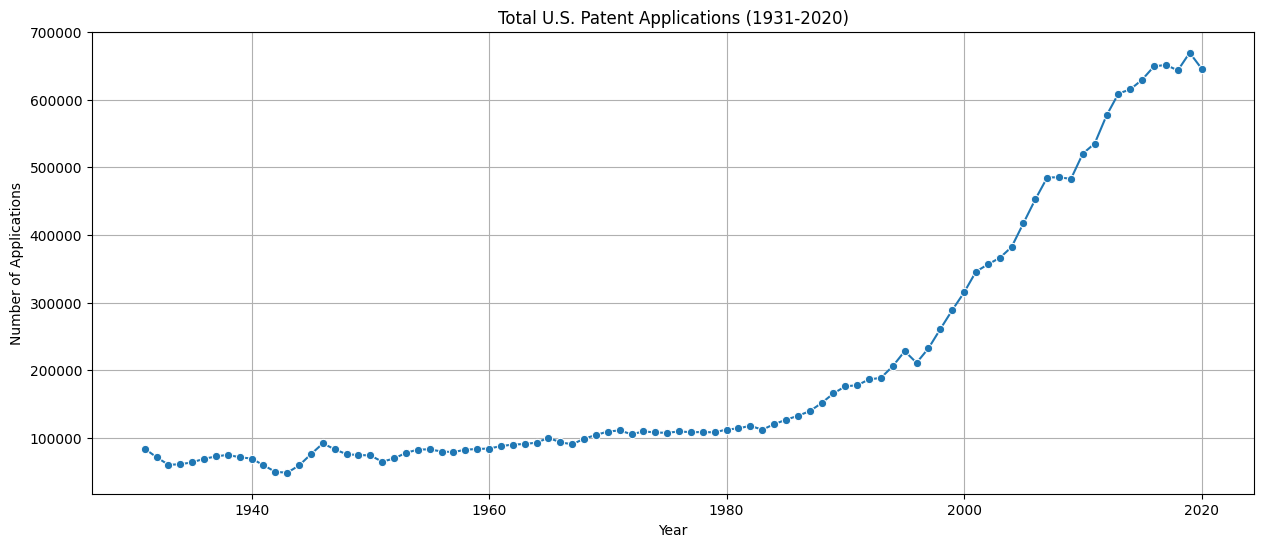

In [147]:
#line plot
plt.figure(figsize=(15, 6))
sns.lineplot(df, x='Calendar Year', y='Total Applications', marker='o')
plt.title('Total U.S. Patent Applications (1931-2020)')
plt.xlabel('Year')
plt.ylabel('Number of Applications')
plt.grid(True)
plt.show()

The line plot above visualizes the trend in total U.S. patent applications from 1931 to 2020. This visualization provides a clear picture of how patent applications have evolved over nearly 90 years, showing any significant increases or decreases that have occurred.

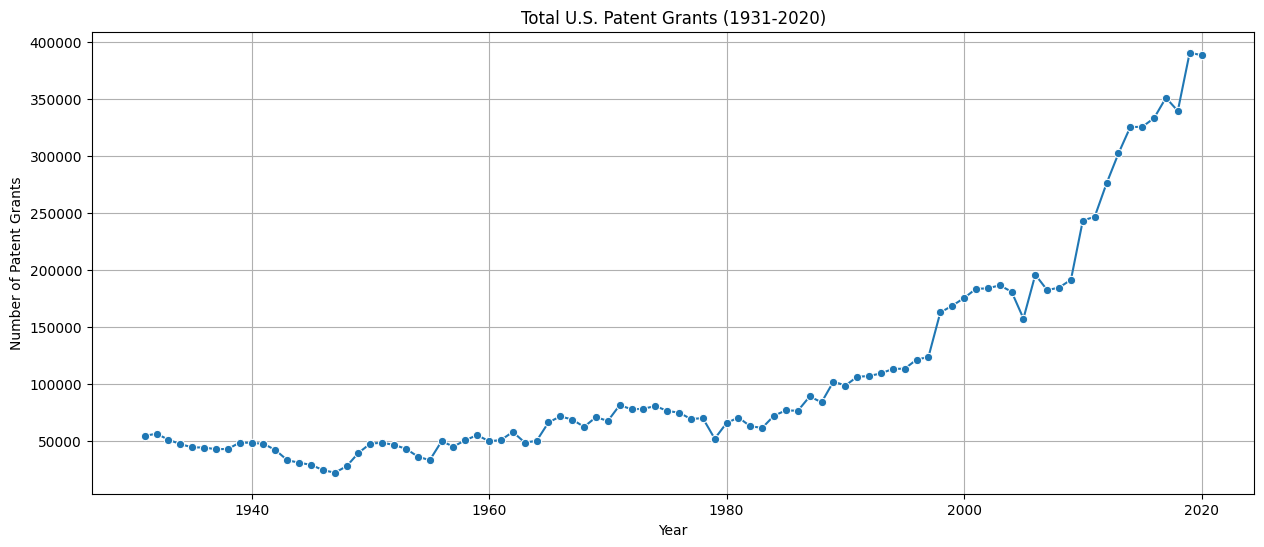

In [148]:
#line plot
plt.figure(figsize=(15, 6))
sns.lineplot(df, x='Calendar Year', y='Total grants', marker='o')
plt.title('Total U.S. Patent Grants (1931-2020)')
plt.xlabel('Year')
plt.ylabel('Number of Patent Grants')
plt.grid(True)
plt.show()

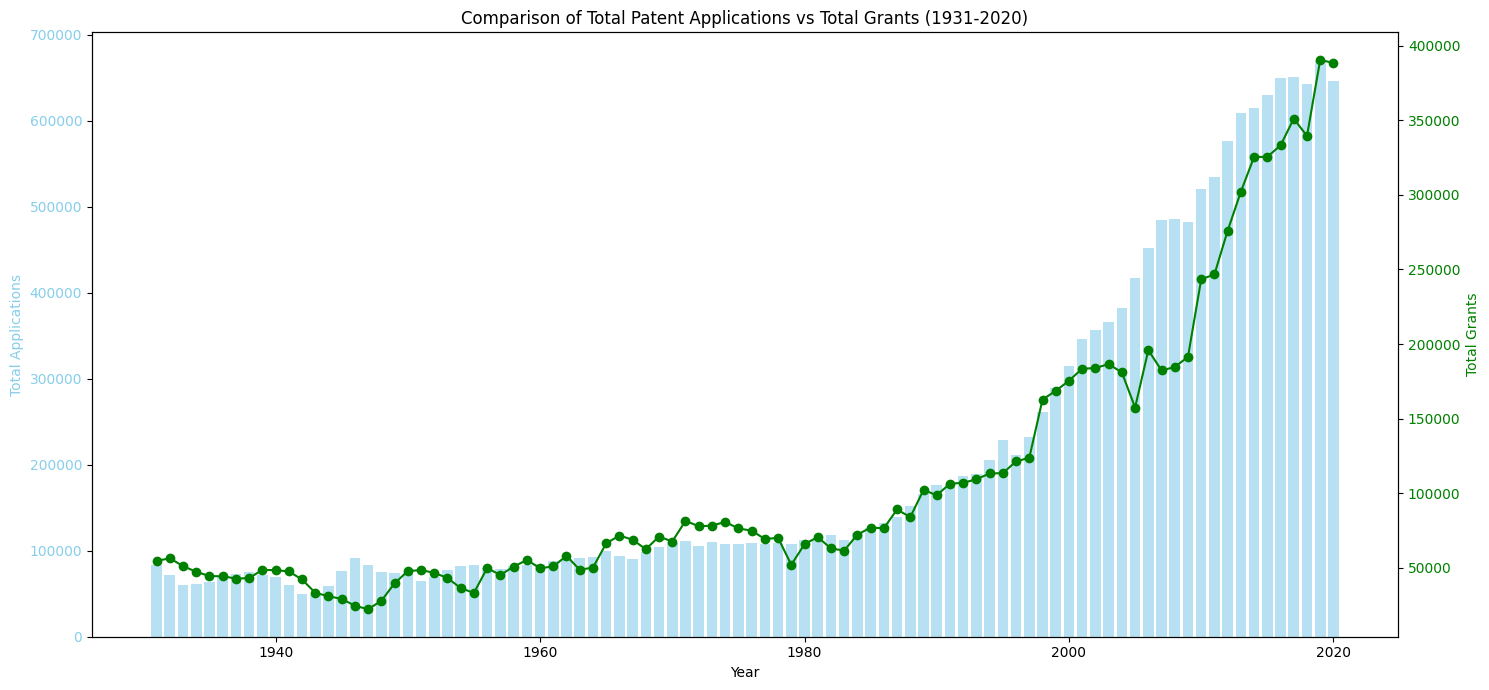

In [149]:
#Bar Plot with Dual Axis
fig, ax1 = plt.subplots(figsize=(15, 7))

# Bar plot for Total Applications
ax1.bar(df['Calendar Year'], df['Total Applications'], color='skyblue', label='Total Applications', alpha=0.6)
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Applications', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# Adding a second y-axis for Total Grants
ax2 = ax1.twinx()
ax2.plot(df['Calendar Year'], df['Total grants'], color='green', label='Total Grants', marker='o')
ax2.set_ylabel('Total Grants', color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title('Comparison of Total Patent Applications vs Total Grants (1931-2020)')
fig.tight_layout()
plt.show()

This visualization compares the trend of total patent applications (shown as bars) with total grants (shown as a line plot) on a year-by-year basis. After 1980, the total numbers of applications and grants began to rise sharply.

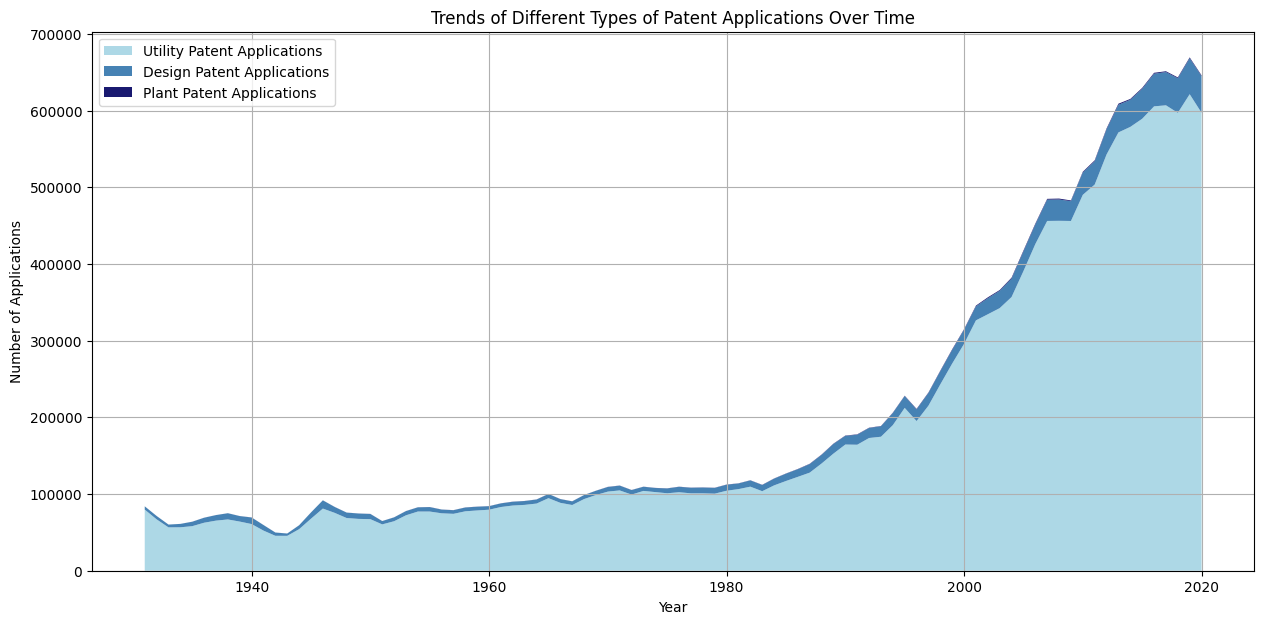

In [150]:
#Stacked Area Plot:
stacked_data_a = df[['Calendar Year', 'Utility Patent Applications', 'Design Patent Applications', 'Plant Patent Applications']]

# Plotting
plt.figure(figsize=(15, 7))
plt.stackplot(stacked_data_a['Calendar Year'], stacked_data_a['Utility Patent Applications'],
              stacked_data_a['Design Patent Applications'], stacked_data_a['Plant Patent Applications'],
              labels=['Utility Patent Applications', 'Design Patent Applications', 'Plant Patent Applications'],
              colors = ['lightblue', 'steelblue', 'midnightblue'])
plt.title('Trends of Different Types of Patent Applications Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Applications')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

This plot shows the trends of different types of patent applications (Utility, Design, and Plant) over time, stacked on top of each other. It provides a visual representation of the proportion of each type of application within the total over the years.

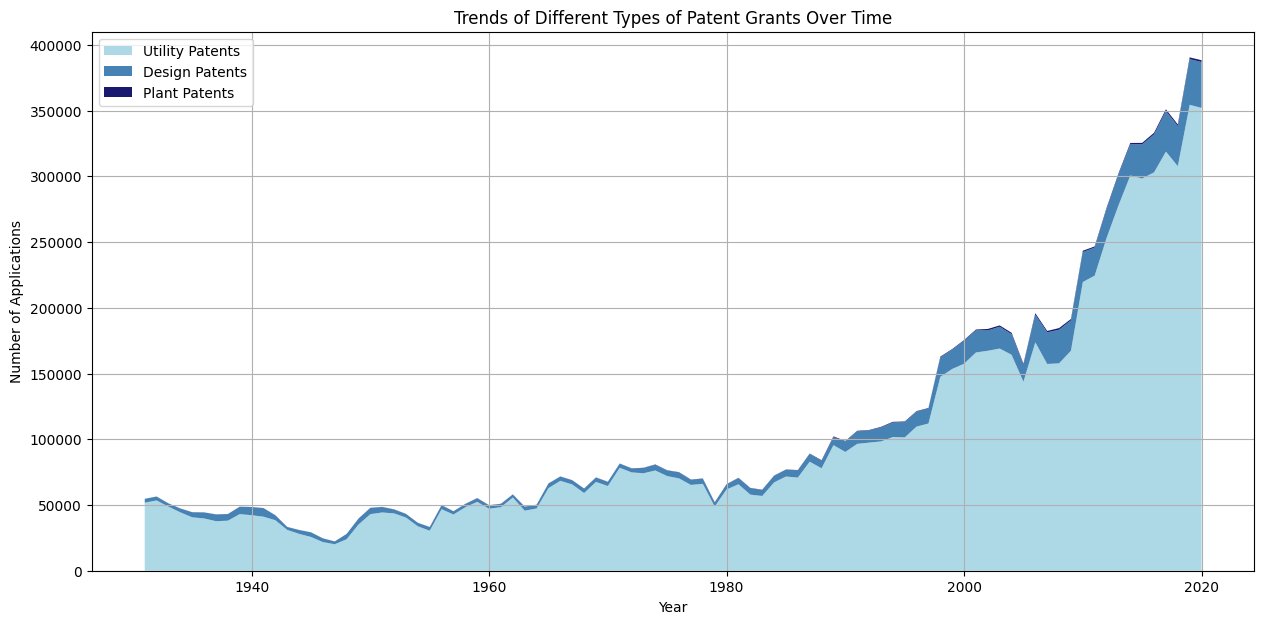

In [151]:
#Stacked Area Plot:
stacked_data_g = df[['Calendar Year', 'Utility Patents', 'Design Patents', 'Plant Patents']]

# Plotting
plt.figure(figsize=(15, 7))
plt.stackplot(stacked_data_g['Calendar Year'], stacked_data_g['Utility Patents'],
              stacked_data_g['Design Patents'], stacked_data_g['Plant Patents'],
              labels=['Utility Patents', 'Design Patents', 'Plant Patents'],
              colors = ['lightblue', 'steelblue', 'midnightblue'])
plt.title('Trends of Different Types of Patent Grants Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Applications')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

This plot shows the trends of different types of patent grants (Utility, Design, and Plant) over time, stacked on top of each other. It provides a visual representation of the proportion of each type of grants within the total over the years.

In [152]:
# Calculate the growth rate
df['Total Applications Growth'] = ((-df['Total Applications'].diff() / df['Total Applications']) * 100).shift(-1)
df['Total Grants Growth'] = ((-df['Total grants'].diff() / df['Total grants']) * 100).shift(-1)
df

,Calendar Year,Utility Patent Applications,Design Patent Applications,Plant Patent Applications,Total Applications,Utility Patents,Design Patents,Plant Patents,Total grants,Total Applications Growth,Total Grants Growth
Calendar Year,,,,,,,,,,,
2020,2020,597175,47838,976,645989,352066,34877,1398,388341,-3.502212,-0.552626
2019,2019,621453,46847,1134,669434,354430,34794,1275,390499,4.062005,15.033995
2018,2018,597141,45083,1079,643303,307759,30497,1208,339464,-1.236192,-3.289089
2017,2017,606956,43340,1059,651355,318828,30870,1311,351009,0.313559,5.358435
2016,2016,605571,42571,1177,649319,303049,28873,1235,333157,3.124290,2.362444
...,...,...,...,...,...,...,...,...,...,...,...
1935,1935,58117,5728,72,63917,40618,3866,45,44529,4.661863,-6.001435
1934,1934,56643,4399,28,61070,44419,2921,32,47372,1.470466,-7.509079
1933,1933,56558,3600,27,60185,48774,2411,33,51218,-15.703741,-9.265164


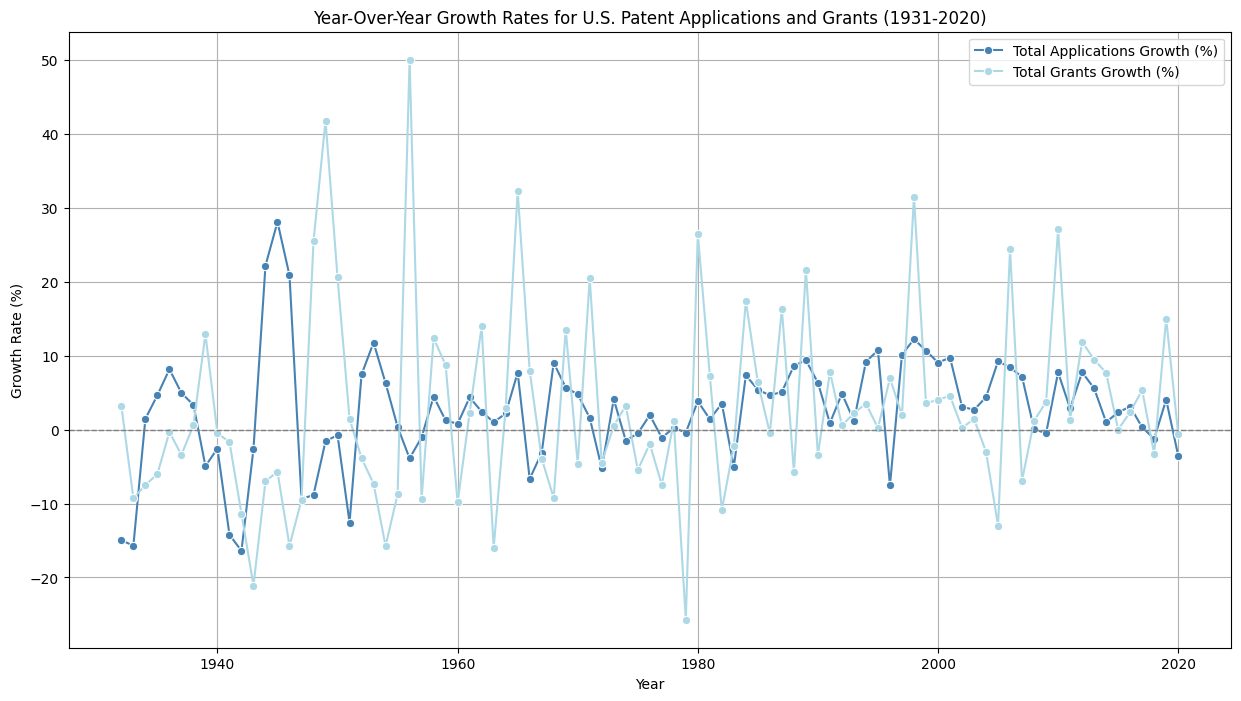

In [153]:
# Plotting Total Applications Growth
plt.figure(figsize=(15, 8))
sns.lineplot(x='Calendar Year', y='Total Applications Growth', data=df, label='Total Applications Growth (%)',
             marker='o', color = 'steelblue')

# Plotting Total Grants Growth
sns.lineplot(x='Calendar Year', y='Total Grants Growth', data=df, label='Total Grants Growth (%)', marker='o', color = 'lightblue')

plt.title('Year-Over-Year Growth Rates for U.S. Patent Applications and Grants (1931-2020)')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.axhline(0, color='grey', lw=1, linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

In [155]:
dfc = pd.read_csv("canada patent 2013-2020.csv", encoding='ISO-8859-1')
dfc

,year,Patent applications
0,2020,37164
1,2019,37999
2,2018,39027
3,2017,34718
4,2016,36019
5,2015,37052
6,2014,37526
7,2013,37044


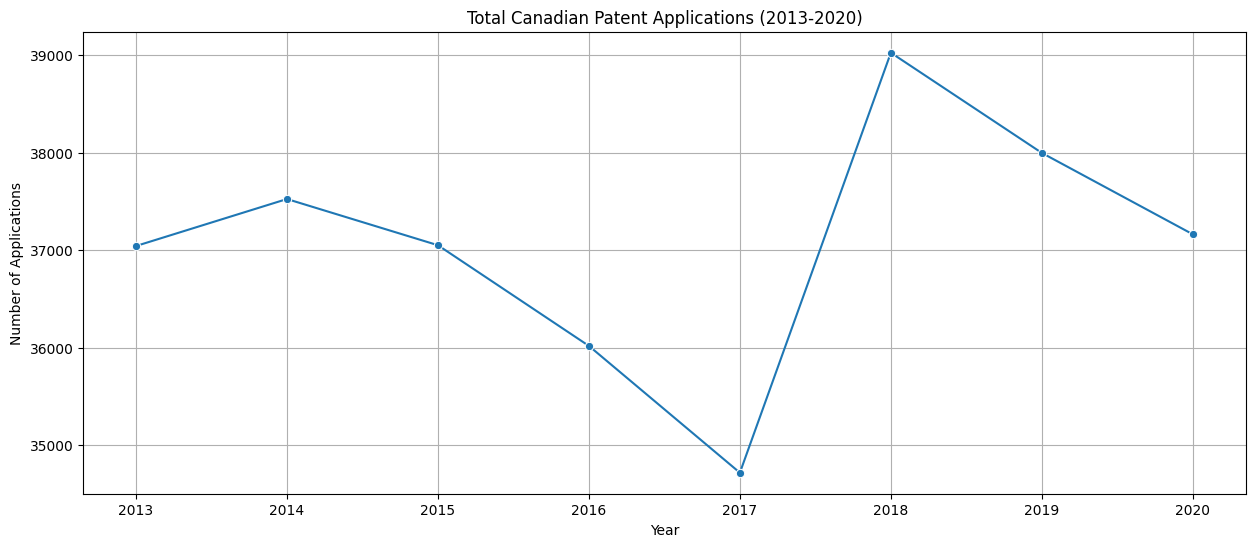

In [156]:
#line plot
plt.figure(figsize=(15, 6))
sns.lineplot(dfc, x='year', y='Patent applications', marker='o')
plt.title('Total Canadian Patent Applications (2013-2020)')
plt.xlabel('Year')
plt.ylabel('Number of Applications')
plt.grid(True)
plt.show()

In [157]:
# Calculating Year-Over-Year Growth Rates for Patent Applications
dfc['Patent applications Growth'] = ((-dfc['Patent applications'].diff() / dfc['Patent applications']) * 100).shift(-1)
dfc.set_index('year', inplace=True)
dfc

,Patent applications,Patent applications Growth
year,,
2020,37164,-2.197426
2019,37999,-2.634074
2018,39027,12.411429
2017,34718,-3.611983
2016,36019,-2.787974
2015,37052,-1.263124
2014,37526,1.301155
2013,37044,NaN


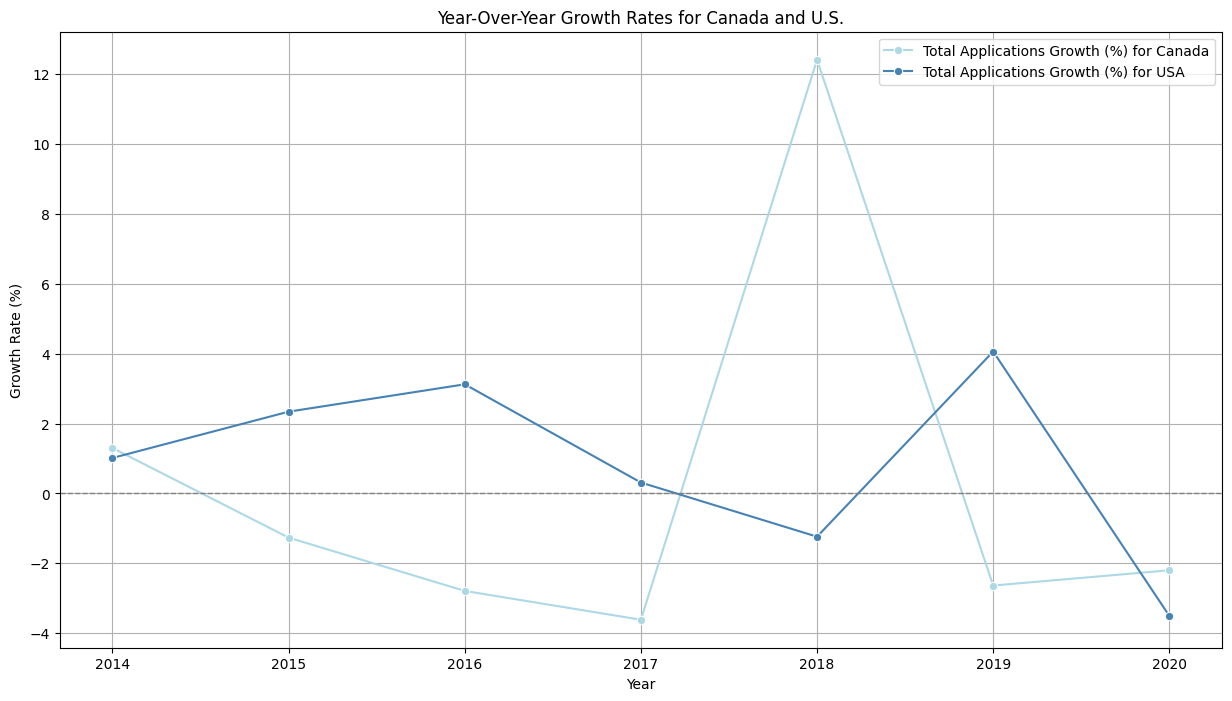

In [158]:
# Plotting Total Applications Growth for Canada
plt.figure(figsize=(15, 8))
sns.lineplot(x='year', y='Patent applications Growth', data=dfc, label='Total Applications Growth (%) for Canada', marker='o',
             color = 'lightblue')

# Plotting Total Applications Growth for the USA
sns.lineplot(x='Calendar Year', y='Total Applications Growth', data=df.head(7), label='Total Applications Growth (%) for USA',
             color = 'steelblue', marker='o')

plt.title('Year-Over-Year Growth Rates for Canada and U.S.')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')
plt.axhline(0, color='grey', lw=1, linestyle='--')
plt.legend()
plt.grid(True)
plt.show()

We can see there is a significant increase in 2017. there are some potential reasons:

Intellectual Property Strategy (2018): In 2018, the Canadian government announced a new Intellectual Property Strategy. This strategy was designed to help Canadian businesses, creators, entrepreneurs, and innovators understand, protect, and access intellectual property through a suite of comprehensive initiatives. These initiatives included education and advice, legislative changes, and support for IP legal clinics.

Canada-European Union Comprehensive Economic and Trade Agreement (CETA): Implemented in September 2017, CETA had implications for intellectual property rights in Canada, including patents. It aimed to improve the legal framework for IP protection and enforcement.

United States-Mexico-Canada Agreement (USMCA): Negotiated to replace NAFTA, the USMCA included various provisions related to intellectual property rights. While it was signed in 2018 and came into effect in July 2020, its negotiation period could have influenced Canada's approach to IP, including patents.

#### 4.1.1 The strategy based on the Feature of Knowledge and Technology Outputs

In [159]:
# Check for stationarity
time_series = df['Total Applications Growth'][:-1]
adf_test = adfuller(time_series)
print('ADF Statistic: %f' % adf_test[0])
print('p-value: %f' % adf_test[1])

ADF Statistic: -1.401477
p-value: 0.581568


In summary, with an ADF statistic of -1.401477 and a p-value of 0.581568, there is strong evidence to show that the data is non-stationary. So we need to difference the data.

In [160]:
#Differencing data
differenced = df['Total Applications Growth'][:-1].diff()
differenced = differenced[1:]
# Check for stationarity
time_series = differenced
adf_test = adfuller(time_series)
print('ADF Statistic: %f' % adf_test[0])
print('p-value: %f' % adf_test[1])

ADF Statistic: -7.521024
p-value: 0.000000


ADF Statistic: More negative values indicate stronger rejection of the null hypothesis.
p-value: This measures the probability of observing the test results under the null hypothesis. A low p-value (typically <= 0.05) indicates strong evidence against the null hypothesis, so reject it. The data is stationary.

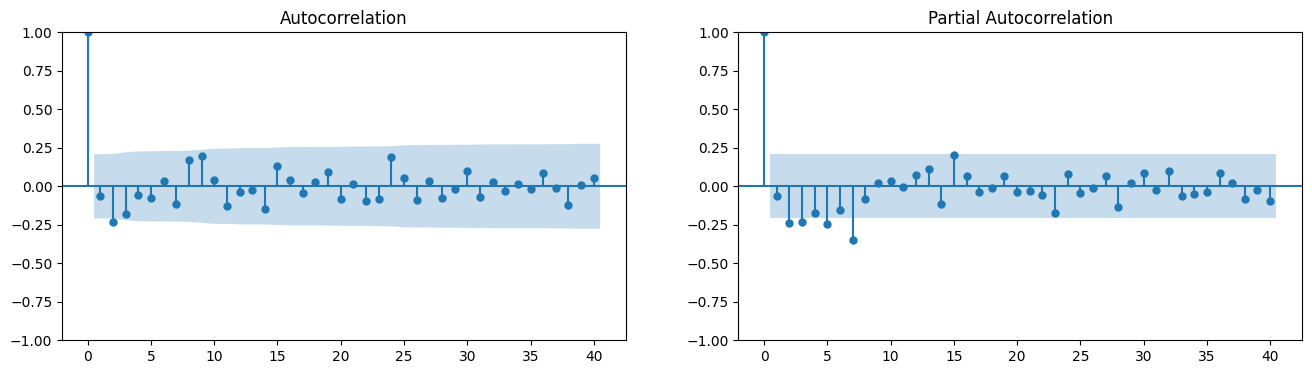

In [161]:
# Plot ACF and PACF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,4))

# Plot the ACF on ax1
plot_acf(time_series, lags=40, ax=ax1)

# Plot the PACF on ax2
plot_pacf(time_series, lags=40, ax=ax2)

plt.show()

Considering these observations, fitting an ARIMA model with p=1 and q=1 depending on the ACF plot at lag 1 is within the confidence interval.

In [162]:
# Split the data into train and test sets
train, test = time_series[int(0.2 * len(time_series)):], time_series[:int(0.2 * len(time_series))]

# Fit the ARIMA model
model = ARIMA(train, order=(1, 1, 1))
fitted_model = model.fit()

# Forecast
forecast = fitted_model.forecast(17)

# Calculate the mean squared error of the forecast
mse = mean_squared_error(test, forecast)
print('Test MSE: %.3f' % mse)

Test MSE: 19.023


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


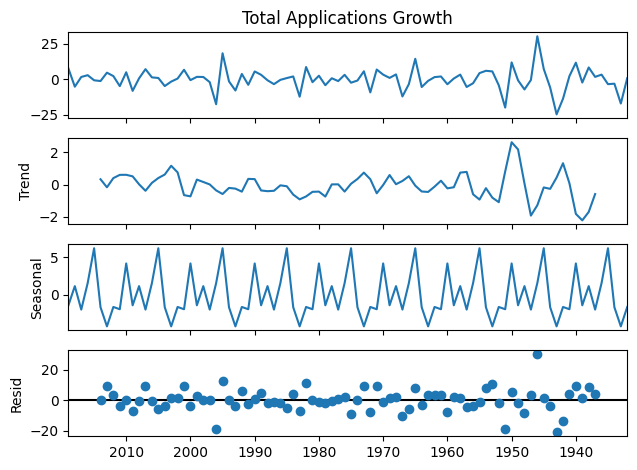

In [163]:
# Seasonal decomposition
decomposition = sm.tsa.seasonal_decompose(time_series, model='additive', period=10)
fig = decomposition.plot()
plt.show()

In [164]:
time_series = df['Total Applications Growth'][:-1]
# Divide the data into train and test sets
train, test = time_series[int(0.2 * len(time_series)):], time_series[:int(0.2 * len(time_series))]

# Simple Exponential Smoothing
ses_model = SimpleExpSmoothing(train).fit()
ses_forecast = ses_model.forecast(17)
ses_mse = mean_squared_error(test, ses_forecast)

# Double Exponential Smoothing
des_model = Holt(train).fit()
des_forecast = des_model.forecast(17)
des_mse = mean_squared_error(test, des_forecast)

# Additive Holt-Winters
hw_add_model = ExponentialSmoothing(train, seasonal='add',seasonal_periods=10).fit()
hw_add_forecast = hw_add_model.forecast(17)
hw_add_mse = mean_squared_error(test, hw_add_forecast)

# Print MSE of all models
print(f'SES MSE: {ses_mse}')
print(f'DES MSE: {des_mse}')
print(f'HW Additive MSE: {hw_add_mse}')

SES MSE: 14.127419697472943
DES MSE: 217.13498255844803
HW Additive MSE: 39.86084629552367


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided a

Since the MES of the Simple Exponential Smoothing model is smallest, we choose this model.

In [165]:
# Forecast for USA and Canadian Growth Rate
actc = dfc['Patent applications Growth'][:-1]
ses_msec = mean_squared_error(actc, ses_forecast[10:])
print(ses_msec)

33.375302010053325


Since the MSE between prediction of this model and Canada growth rate is reasonable, this model also can be fitted to canada data.

In [166]:
ses_forecast_ca = ses_model.forecast(27)
print(ses_forecast_ca[17:])

89    2.678874
90    2.678874
91    2.678874
92    2.678874
93    2.678874
94    2.678874
95    2.678874
96    2.678874
97    2.678874
98    2.678874
dtype: float64


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Specifically, the prediction growth rates over 10 years are 2.678874%.

### 4.2 Feature: Human Capital and Research


In [168]:
import pandas as pd
df = pd.read_csv('National_R&D(GDP%).csv')

df=df.drop(['INDICATOR','SUBJECT','MEASURE','FREQUENCY','Flag Codes'],axis=1)

location_mapping = {
    'DEU': 'Germany',
    'CAN': 'Canada',
    'JPN': 'Japan',
    'CHE': 'Switzerland',
    'GBR': 'UK',
    'USA': 'USA',
    'SGP': 'Singapore'}

df['LOCATION'] = df['LOCATION'].replace(location_mapping)

df_canada = df[df['LOCATION'] == 'Canada']
mean_value_canada_15_years = df_canada[df_canada['TIME'].between(2008, 2022)]['Value'].mean()
print("Mean Canada R&D GDP% Value for the Nearest 15 Years:", mean_value_canada_15_years)

Mean Canada R&D GDP% Value for the Nearest 15 Years: 1.7550027744453267


The targeted goal for our proposed program is to elevate Canada's R&D spending to 1.75% of the total GDP by 2025, aligning with the mean R&D GDP% value for the nearest 15 years at 1.756%. It's worth noting that Canada's R&D spending was approximately 1.55% of the GDP in 2022, making our strategies' objective both realistic and feasible.

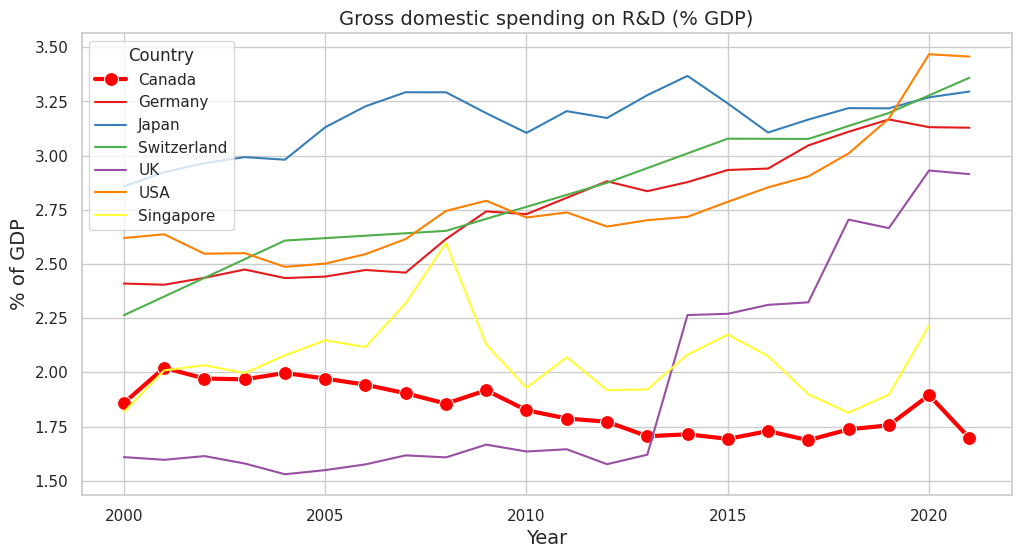

In [169]:
df.drop(22, inplace=True) # extra than other countries data

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")
sns.lineplot(data=df[df['LOCATION'] == 'Canada'], x='TIME', y='Value', marker='o',
             markersize=10, linewidth=3, color='red',label='Canada')
sns.lineplot(data=df[df['LOCATION'] != 'Canada'], x='TIME', y='Value', hue='LOCATION', markersize=8, palette='Set1')

plt.title('Gross domestic spending on R&D (% GDP)', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.ylabel('% of GDP', fontsize=14)

plt.legend(title='Country', loc='upper left')
plt.show()

In [170]:
country_df = df.pivot(index='TIME', columns='LOCATION', values='Value')
country_df = country_df[country_df.index > 2008]
RD_change=country_df.pct_change()*100
RD_change

LOCATION,Canada,Germany,Japan,Singapore,Switzerland,UK,USA
TIME,,,,,,,
2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010,-4.805315,-0.453033,-2.845742,-9.338821,NaN,-1.897425,-2.771356
2011,-2.089378,2.758328,3.234019,7.275994,NaN,0.625862,0.869035
2012,-0.828828,2.712815,-0.987742,-7.306652,NaN,-4.187647,-2.381203
2013,-3.776055,-1.584818,3.316336,0.141026,0.000000,2.778402,1.096635
2014,0.514169,1.475816,2.711813,8.393506,0.000000,39.774672,0.581460
2015,-1.220997,1.944210,-3.775909,4.426299,7.088210,0.254956,2.543761
2016,2.113213,0.224878,-4.136469,-4.586759,0.000000,1.813566,2.386281
2017,-2.429499,3.629122,1.921671,-8.482651,-0.043680,0.508463,1.781087


In [171]:
selected_data = RD_change.loc[2008:, ['Germany', 'Japan', 'Switzerland', 'USA']]
average_values = selected_data.mean()
average_values
# 4 countries average
print(average_values.mean())

1.2577805386566923


We determine the average annual R&D spending percentage change over the most recent 15 years for selected countries (Germany, Japan, Switzerland, and the USA), resulting in a mean of approximately 1.26% per year. Considering Canada's R&D spending at around 1.55% of the GDP in 2022, our objective is to elevate it to 1.95% by the end of the 5-year program in 2029, calculated as 1.55 multiplied by 1.26. Based on the Gross domestic spending on R&D (% GDP)​ plot, Canada's Gross Domestic Spending on Research and Development (% GDP) lags behind that of other nations. To enhance the Canada Innovation Measure Index, it is imperative to boost net national spending in R&D. To achieve this, we will propose a strategy focusing on increasing R&D funding.  Since various R&D funding sources across sectors, therefore we would find the most important sector and propose strategy focus on it.

In [172]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv('government_R&D budget.csv')

# Create DataFrame
budget = pd.DataFrame(data)
budget = budget.dropna()

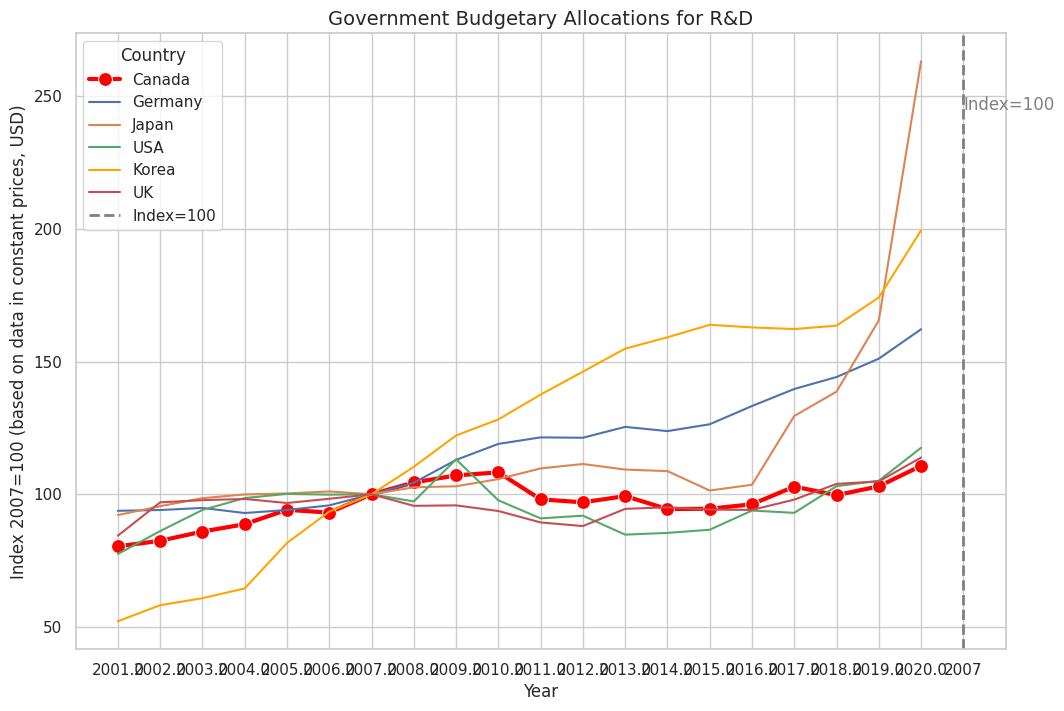

In [173]:
budget['Year'] = budget['Year'].astype(str)

plt.figure(figsize=(12, 8))

sns.lineplot(data=budget, x='Year', y='Canada', label='Canada',marker='o',
             markersize=10, linewidth=3, color='red')
sns.lineplot(data=budget, x='Year', y='Germany', label='Germany')
sns.lineplot(data=budget, x='Year', y='Japan', label='Japan')
sns.lineplot(data=budget, x='Year', y='US', label='USA')
sns.lineplot(data=budget, x='Year', y='Korea', label='Korea', color='orange')
sns.lineplot(data=budget, x='Year', y='UK', label='UK')

plt.title('Government Budgetary Allocations for R&D',fontsize=14)
plt.xlabel('Year')
plt.ylabel('Index 2007=100 (based on data in constant prices, USD)')

plt.axvline(x='2007', linestyle='--', linewidth=2, color='gray', label='Index=100')
plt.text('2007', 250, 'Index=100', color='gray', verticalalignment='top')

plt.legend(title='Country', loc='upper left')
plt.show()

Based on the plots above, the government budget for R&D in Canada is also less than the other countries.

In [174]:
!pip install openpyxl

In [175]:
import pandas as pd
USdf = pd.read_excel('U.S. R&D expenditures, by source of funds and performing sector.xlsx')

In [176]:
USdf = USdf.iloc[50:71, :]
USdf = USdf.loc[:, ['Year', 'All funding sources', 'Federal', 'Nonfederal government', 'Business', 'Higher education', 'NPOs']]
USdf.columns = ['Year', 'Total fundings(current $)', 'Federal government', 'Nonfederal government', 'Business', 'Higher education', 'NPOs']
USdf = USdf.reset_index(drop=True)
USdf.iloc[19,0]=2020
USdf.iloc[20,0]=2021
USdf

,Year,Total fundings(current $),Federal government,Nonfederal government,Business,Higher education,NPOs
0,2001,278539,73793,2341,188408,6874,7122
1,2002,277911,78873,2553,180704,7673,8109
2,2003,291365,85133,2788,186171,8286,8988
3,2004,302731,90795,2926,191346,8637,9028
4,2005,325288,95413,2977,207775,9353,9771
5,2006,350908,99938,3293,227182,10176,10320
6,2007,377890,105128,3594,246815,10933,11420
7,2008,404777,117615,4221,258020,11738,13184
8,2009,402932,125765,4296,246609,12057,14205
9,2010,406600,126617,4303,248126,12262,15292


In [177]:
USdf_percentage = pd.DataFrame({'Year': USdf['Year'], 'Total fundings(current $)': USdf['Total fundings(current $)']})
# Compute the percentage of each fundings provided by each sector
percentage_columns = ['Federal government', 'Nonfederal government', 'Business', 'Higher education', 'NPOs']
for col in percentage_columns:
    USdf_percentage[col] = (USdf[col] / USdf['Total fundings(current $)'])*100

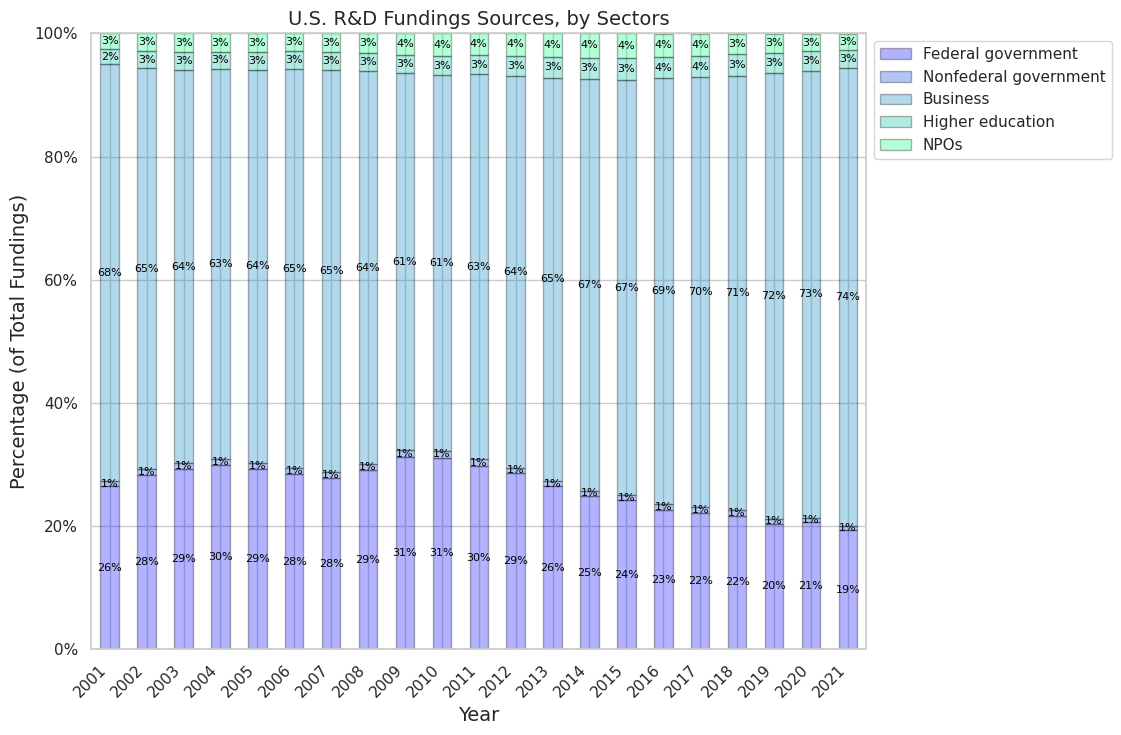

In [178]:
import pandas as pd
import matplotlib.pyplot as plt

USdf_bar = USdf_percentage.drop('Total fundings(current $)', axis=1)
USdf_bar.set_index('Year', inplace=True)

ax = USdf_bar.plot(
    kind='bar',
    stacked=True,
    colormap='winter',
    alpha=0.3,
    edgecolor='black',
    figsize=(10, 8))

ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Percentage (of Total Fundings)", fontsize=14)
ax.set_title("U.S. R&D Fundings Sources, by Sectors", fontsize=14)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.set_ylim(0, 100)
y_ticks = [0, 20, 40, 60, 80, 100]
y_labels = ['{}%'.format(val) for val in y_ticks]
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# add rounded percentage labels in the center of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='center', fontsize=8, color='black')

plt.show()

In [179]:
import pandas as pd
CAdf = pd.read_csv('Research Funding Sources CA_Clean.csv')
CAdf['Total Funding'] = CAdf.iloc[:,1:].sum(axis=1)

In [180]:
new_column_names = {'REF_DATE': 'Year'}
CAdf.rename(columns=new_column_names, inplace=True)

In [181]:
CAdf_percentage = pd.DataFrame({'Year': CAdf['Year']})
# compute the percentage of each fundings provided by each sector
percentage_columns = ['Business enterprise', 'Federal government', 'Foreign sources',
                      'From general university funds', 'From own revenue sources',
                      'Higher education', 'Private non-profit', 'Provincial governments']
for col in percentage_columns:
    CAdf_percentage[col] = (CAdf[col] / CAdf['Total Funding'])*100

In [182]:
CAdf_percentage['Business enterprise'] = CAdf_percentage['Business enterprise'] + CAdf_percentage['From own revenue sources']
CAdf_percentage.drop('From own revenue sources', axis=1, inplace=True)

CAdf_percentage['Higher education'] = CAdf_percentage['Higher education'] + CAdf_percentage['From general university funds']
CAdf_percentage.drop('From general university funds', axis=1, inplace=True)

In [183]:
CAdf_percentage.rename(columns={'Business enterprise': 'Business',
                                'Private non-profit': 'NPOs'}, inplace=True)

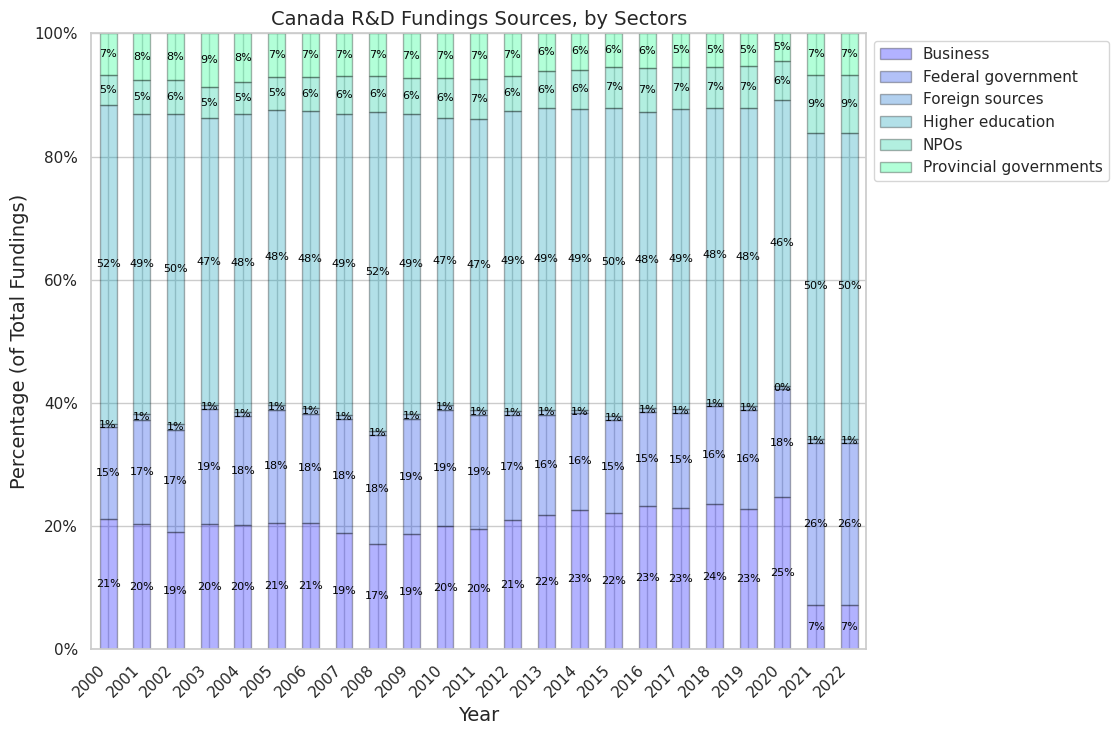

In [184]:
import pandas as pd
import matplotlib.pyplot as plt

CAdf_percentage.set_index('Year', inplace=True)
ax = CAdf_percentage.plot(
    kind='bar',
    stacked=True,
    colormap='winter',
    alpha=0.3,
    edgecolor='black',
    figsize=(10, 8))

ax.set_xlabel("Year", fontsize=14)
ax.set_ylabel("Percentage (of Total Fundings)", fontsize=14)
ax.set_title("Canada R&D Fundings Sources, by Sectors", fontsize=14)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.set_ylim(0, 100)
y_ticks = [0, 20, 40, 60, 80, 100]
y_labels = ['{}%'.format(val) for val in y_ticks]
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# add rounded percentage labels in the center of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='center', fontsize=8, color='black')

plt.show()

Analyzing the distribution of R&D funds across sectors in the USA and Canada reveals an opportunity for Canadian business enterprises to augment their R&D spending, a notable sector difference compared to the USA's business enterprises. Therefore, we propose our strategy (InnoHarbor Canada Program (IHCP)), which is designed to stimulate private enterprises to conduct research by providing exclusive access to government-funded incubators and networking platforms, thereby increasing investment in Research and Development (R&D) and the innovation landscape of Canada.